In [26]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from minisom import MiniSom

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

SOM_X = 12
SOM_Y = 12
SOM_ITERS = 5000
N_CLUSTERS = 6

OUT_GPKG = os.path.join(BASE_DIR, "som_final_clean.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "som_final_clean.png")
OUT_METRICS = os.path.join(BASE_DIR, "som_final_metrics.txt")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name: str) -> str:
    return os.path.join(SHP_DIR, name)


def load_layer(path: str) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask: gpd.GeoDataFrame, gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask: gpd.GeoDataFrame, cell_size: int) -> gpd.GeoDataFrame:
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid: gpd.GeoDataFrame, source: gpd.GeoDataFrame, name: str) -> gpd.GeoDataFrame:
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance: pd.Series, scale: float) -> np.ndarray:
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def collect_points(mask: gpd.GeoDataFrame) -> gpd.GeoDataFrame | None:
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" in geom_types or "MultiPoint" in geom_types:
            gdf = gdf[gdf.geometry.notnull()].copy()
            gdf = gdf[~gdf.geometry.is_empty].copy()
            gdf = to_mask_crs(mask, gdf)
            gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()
            if len(gdf) > 0:
                point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

grid["geo_score_raw"] = (
    1.4 * grid["prox_tect1"] +
    1.4 * grid["prox_tect2"] +
    1.2 * grid["prox_magm"] +
    1.1 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.5 * grid["tect_intersection"] +
    0.4 * grid["tect_magm_intersection"] +
    0.3 * grid["tect_struct_intersection"] +
    0.2 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================================================
# TARGET
# =========================================================
grid["target"] = 0
use_supervised = False

if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(
            points,
            grid[["cell_id", "geometry"]],
            how="left",
            predicate="within"
        )
    except Exception:
        joined = gpd.sjoin(
            points,
            grid[["cell_id", "geometry"]],
            how="left",
            op="within"
        )

    positive_cells = joined["cell_id"].dropna().unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target"] = 1

    if grid["target"].sum() >= 5 and grid["target"].sum() < len(grid):
        use_supervised = True


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
if use_supervised:
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X, grid["target"])
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])
else:
    grid["ml_score"] = grid["geo_score"]


# =========================================================
# SOM
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

som = MiniSom(
    x=SOM_X,
    y=SOM_Y,
    input_len=X_scaled.shape[1],
    sigma=1.3,
    learning_rate=0.45,
    random_seed=RANDOM_STATE
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, SOM_ITERS)

winners = np.array([som.winner(x) for x in X_scaled])
grid["som_x"] = winners[:, 0]
grid["som_y"] = winners[:, 1]
grid["som_node"] = grid["som_x"].astype(str) + "_" + grid["som_y"].astype(str)

som_weights = som.get_weights().reshape(SOM_X * SOM_Y, X_scaled.shape[1])
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
neuron_cluster = kmeans.fit_predict(som_weights)

node_to_cluster = {}
idx = 0
for i in range(SOM_X):
    for j in range(SOM_Y):
        node_to_cluster[f"{i}_{j}"] = int(neuron_cluster[idx])
        idx += 1

grid["cluster"] = grid["som_node"].map(node_to_cluster).astype(int)


# =========================================================
# CLUSTER SCORE
# =========================================================
cluster_geo = grid.groupby("cluster")["geo_score"].mean().reset_index(name="cluster_geo_mean")
cluster_ml = grid.groupby("cluster")["ml_score"].mean().reset_index(name="cluster_ml_mean")
cluster_stats = cluster_geo.merge(cluster_ml, on="cluster", how="outer")

if use_supervised:
    cluster_hits = (
        grid.groupby("cluster")
        .agg(cells=("cell_id", "count"), positives=("target", "sum"))
        .reset_index()
    )
    cluster_hits["hit_rate"] = cluster_hits["positives"] / cluster_hits["cells"]

    cluster_stats = cluster_stats.merge(cluster_hits, on="cluster", how="left")
    cluster_stats["hit_rate"] = cluster_stats["hit_rate"].fillna(0)

    cluster_stats["cluster_score"] = normalize_01(
        0.50 * cluster_stats["cluster_ml_mean"] +
        0.30 * cluster_stats["cluster_geo_mean"] +
        0.20 * normalize_01(cluster_stats["hit_rate"])
    )
else:
    cluster_stats["cluster_score"] = normalize_01(
        0.60 * cluster_stats["cluster_ml_mean"] +
        0.40 * cluster_stats["cluster_geo_mean"]
    )

cluster_score_map = dict(zip(cluster_stats["cluster"], cluster_stats["cluster_score"]))
grid["cluster_score"] = grid["cluster"].map(cluster_score_map).astype(float)


# =========================================================
# ИТОГ
# =========================================================
if use_supervised:
    grid["prospectivity_raw"] = (
        0.55 * grid["ml_score"] +
        0.25 * grid["cluster_score"] +
        0.20 * grid["geo_score"]
    )
else:
    grid["prospectivity_raw"] = (
        0.50 * grid["cluster_score"] +
        0.50 * grid["geo_score"]
    )

grid["local_bonus"] = normalize_01(
    0.4 * grid["tect_intersection"] +
    0.35 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"]
)

grid["prospectivity_raw"] += 0.08 * grid["local_bonus"]
grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# МЕТРИКИ
# =========================================================
metrics_lines = []

if use_supervised:
    y_true = grid["target"].astype(int).values
    y_score = grid["prospectivity"].astype(float).values
    y_pred = (y_score >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    top10_cells = int(grid["top10"].sum())
    positive_total = int(grid["target"].sum())
    positive_in_top10 = int(grid.loc[grid["top10"] == 1, "target"].sum())

    hit_rate_top10 = positive_in_top10 / positive_total if positive_total > 0 else 0.0
    precision_top10 = positive_in_top10 / top10_cells if top10_cells > 0 else 0.0
    base_rate = positive_total / len(grid) if len(grid) > 0 else 0.0
    lift_top10 = precision_top10 / base_rate if base_rate > 0 else 0.0

    grid["pred_05"] = y_pred

    metrics_lines.append("=== MODEL METRICS ===")
    metrics_lines.append(f"ROC AUC: {roc_auc:.4f}")
    metrics_lines.append(f"PR AUC: {pr_auc:.4f}")
    metrics_lines.append(f"Precision@0.5: {precision:.4f}")
    metrics_lines.append(f"Recall@0.5: {recall:.4f}")
    metrics_lines.append(f"F1@0.5: {f1:.4f}")
    metrics_lines.append("")
    metrics_lines.append("=== CONFUSION MATRIX @0.5 ===")
    metrics_lines.append(f"TP: {tp}")
    metrics_lines.append(f"FP: {fp}")
    metrics_lines.append(f"TN: {tn}")
    metrics_lines.append(f"FN: {fn}")
    metrics_lines.append("")
    metrics_lines.append("=== TOP10 ZONES ===")
    metrics_lines.append(f"Top10 cells: {top10_cells}")
    metrics_lines.append(f"Positive cells total: {positive_total}")
    metrics_lines.append(f"Positive cells in Top10: {positive_in_top10}")
    metrics_lines.append(f"HitRate_Top10: {hit_rate_top10:.4f}")
    metrics_lines.append(f"Precision_Top10: {precision_top10:.4f}")
    metrics_lines.append(f"BaseRate: {base_rate:.4f}")
    metrics_lines.append(f"Lift_Top10: {lift_top10:.4f}")

    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")
    print(f"Precision@0.5: {precision:.4f}")
    print(f"Recall@0.5: {recall:.4f}")
    print(f"F1@0.5: {f1:.4f}")
    print(f"HitRate_Top10: {hit_rate_top10:.4f}")
    print(f"Lift_Top10: {lift_top10:.4f}")

else:
    grid["pred_05"] = 0
    metrics_lines.append("=== MODEL METRICS ===")
    metrics_lines.append("Supervised metrics are unavailable because target labels are insufficient.")
    print("Supervised metrics are unavailable because target labels are insufficient.")


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="som_final_clean", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")

with open(OUT_METRICS, "w", encoding="utf-8") as f:
    f.write("\n".join(metrics_lines))


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=12,
        edgecolor="black",
        linewidth=0.3
    )

ax.set_title("SOM + supervised прогноз перспективности")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()

print("Готово.")

ROC AUC: 0.6629
PR AUC: 0.0087
Precision@0.5: 0.0069
Recall@0.5: 0.5970
F1@0.5: 0.0135
HitRate_Top10: 0.2388
Lift_Top10: 2.3871
Готово.


KeyboardInterrupt: 

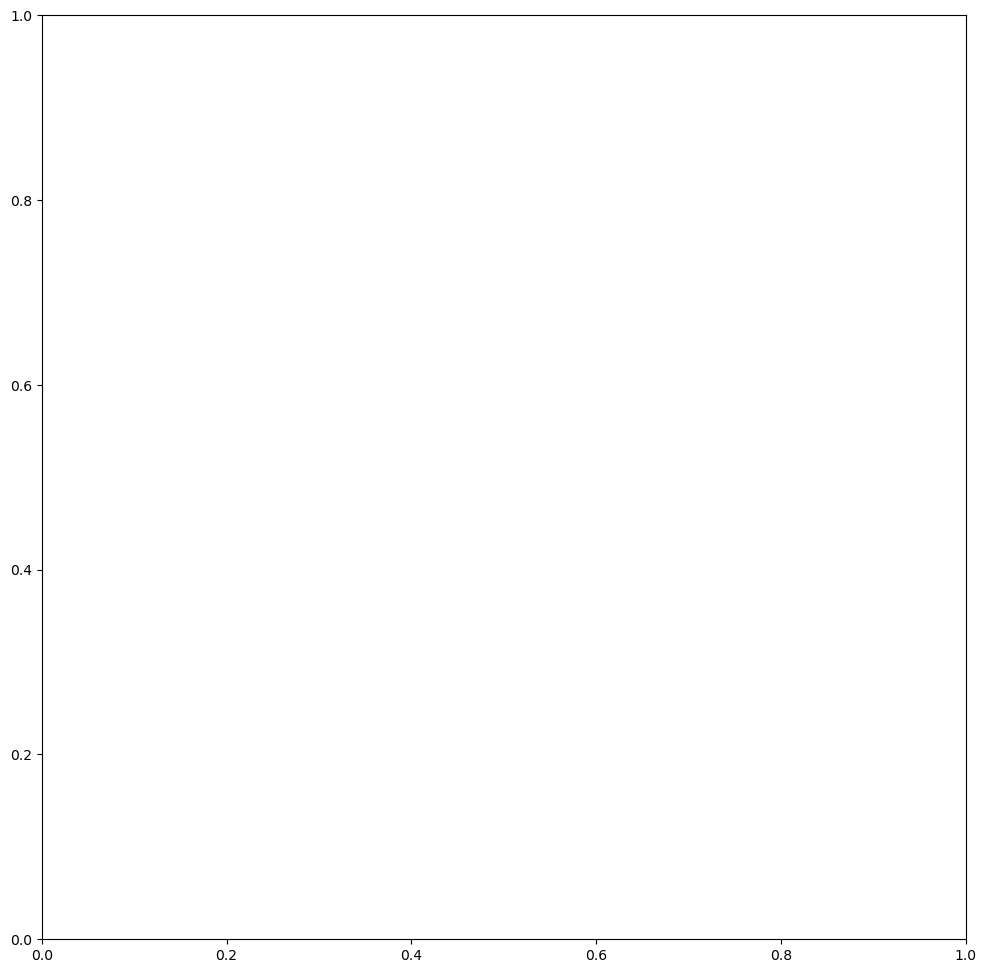

In [27]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

OUT_GPKG = os.path.join(BASE_DIR, "prognoz_final_clean.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "prognoz_final_clean.png")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def is_target_file(shp_path):
    """
    Фильтр point-слоев для target.
    Оставляем только файлы, которые по имени похожи на Au/U.
    При необходимости подправь под свои реальные имена файлов.
    """
    name = os.path.basename(shp_path).lower()

    keywords = [
        "au", "gold", "zolot",
        "u", "uran", "uranium",
        "gold_uran", "au_u"
    ]

    return any(k in name for k in keywords)


def filter_target_points(gdf):
    """
    Дополнительная фильтрация по атрибутам.
    Если в точечном слое есть текстовые поля с типом минерала,
    пытаемся оставить только Au/U.
    Если подходящих полей нет, возвращаем слой как есть.
    """
    text_cols = [c for c in gdf.columns if gdf[c].dtype == object]

    if len(text_cols) == 0:
        return gdf

    patterns = ["au", "gold", "zolot", "u", "uran"]

    mask = None
    for col in text_cols:
        values = gdf[col].astype(str).str.lower()
        col_mask = values.apply(lambda x: any(p in x for p in patterns))
        mask = col_mask if mask is None else (mask | col_mask)

    if mask is not None and mask.sum() > 0:
        return gdf[mask].copy()

    return gdf


def collect_points(mask):
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        if not is_target_file(shp):
            continue

        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" in geom_types or "MultiPoint" in geom_types:
            gdf = gdf[gdf.geometry.notnull()].copy()
            gdf = gdf[~gdf.geometry.is_empty].copy()
            gdf = to_mask_crs(mask, gdf)
            gdf = filter_target_points(gdf)
            gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()

            if len(gdf) > 0:
                point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

grid["geo_score_raw"] = (
    1.4 * grid["prox_tect1"] +
    1.4 * grid["prox_tect2"] +
    1.2 * grid["prox_magm"] +
    1.1 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.5 * grid["tect_intersection"] +
    0.4 * grid["tect_magm_intersection"] +
    0.3 * grid["tect_struct_intersection"] +
    0.2 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================================================
# TARGET
# =========================================================
grid["target"] = 0
use_supervised = False

if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(
            points,
            grid[["cell_id", "geometry"]],
            how="left",
            predicate="within"
        )
    except Exception:
        joined = gpd.sjoin(
            points,
            grid[["cell_id", "geometry"]],
            how="left",
            op="within"
        )

    positive_cells = joined["cell_id"].dropna().unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target"] = 1

    if grid["target"].sum() >= 5 and grid["target"].sum() < len(grid):
        use_supervised = True

y_true = grid["target"].values.copy()


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
if use_supervised:
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X, grid["target"])
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])

    coef_table = pd.DataFrame({
        "feature": feature_cols,
        "weight": lr.coef_[0]
    }).sort_values("weight", ascending=False)

    print("\nВеса факторов Logistic Regression:")
    print(coef_table.to_string(index=False))
else:
    grid["ml_score"] = grid["geo_score"]


# =========================================================
# ИТОГ
# =========================================================
if use_supervised:
    grid["prospectivity_raw"] = (
        0.75 * grid["ml_score"] +
        0.25 * grid["geo_score"]
    )
else:
    grid["prospectivity_raw"] = grid["geo_score"]

grid["local_bonus"] = normalize_01(
    0.4 * grid["tect_intersection"] +
    0.35 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"]
)

grid["prospectivity_raw"] += 0.08 * grid["local_bonus"]
grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

y_score = grid["prospectivity"].values.copy()

grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="prognoz_final_clean", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=12,
        edgecolor="black",
        linewidth=0.3
    )

ax.set_title("Supervised прогноз перспективности")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()


# =========================================================
# МЕТРИКИ
# =========================================================
print("\n========== МЕТРИКИ ==========")

if np.sum(y_true) > 0 and np.sum(y_true) < len(y_true):
    threshold_metric = np.quantile(y_score, 0.9)
    y_pred = (y_score >= threshold_metric).astype(int)

    try:
        auc = roc_auc_score(y_true, y_score)
        print(f"ROC-AUC: {auc:.3f}")
    except Exception:
        print("ROC-AUC: ошибка")

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")

    hits = np.sum((y_true == 1) & (y_pred == 1))
    total_pos = np.sum(y_true)

    if total_pos > 0:
        print(f"Recall@Top10%: {hits / total_pos:.3f}")
else:
    print("Недостаточно данных для расчёта метрик")

print("Готово.")

In [28]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

OUT_GPKG = os.path.join(BASE_DIR, "prognoz_final_clean.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "prognoz_final_clean.png")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def filter_target_points(gdf):
    """
    Пытается оставить только Au/U по текстовым атрибутам.
    Если подходящих полей или значений нет, возвращает слой как есть.
    """
    text_cols = [c for c in gdf.columns if gdf[c].dtype == object]

    if len(text_cols) == 0:
        return gdf

    patterns = ["au", "gold", "zolot", "u", "uran"]

    mask = None
    for col in text_cols:
        values = gdf[col].astype(str).str.lower()
        col_mask = values.apply(lambda x: any(p in x for p in patterns))
        mask = col_mask if mask is None else (mask | col_mask)

    if mask is not None and mask.sum() > 0:
        return gdf[mask].copy()

    return gdf


def collect_points(mask):
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" in geom_types or "MultiPoint" in geom_types:
            gdf = gdf[gdf.geometry.notnull()].copy()
            gdf = gdf[~gdf.geometry.is_empty].copy()
            gdf = to_mask_crs(mask, gdf)
            gdf = filter_target_points(gdf)
            gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()

            if len(gdf) > 0:
                point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

grid["geo_score_raw"] = (
    1.4 * grid["prox_tect1"] +
    1.4 * grid["prox_tect2"] +
    1.2 * grid["prox_magm"] +
    1.1 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.5 * grid["tect_intersection"] +
    0.4 * grid["tect_magm_intersection"] +
    0.3 * grid["tect_struct_intersection"] +
    0.2 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================================================
# TARGET
# =========================================================
grid["target"] = 0
use_supervised = False

if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(
            points,
            grid[["cell_id", "geometry"]],
            how="left",
            predicate="within"
        )
    except Exception:
        joined = gpd.sjoin(
            points,
            grid[["cell_id", "geometry"]],
            how="left",
            op="within"
        )

    positive_cells = joined["cell_id"].dropna().unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target"] = 1

    if grid["target"].sum() >= 5 and grid["target"].sum() < len(grid):
        use_supervised = True

y_true = grid["target"].values.copy()


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
if use_supervised:
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X, grid["target"])
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])

    coef_table = pd.DataFrame({
        "feature": feature_cols,
        "weight": lr.coef_[0]
    }).sort_values("weight", ascending=False)

    print("\nВеса факторов Logistic Regression:")
    print(coef_table.to_string(index=False))
else:
    grid["ml_score"] = grid["geo_score"]


# =========================================================
# ИТОГ
# =========================================================
if use_supervised:
    grid["prospectivity_raw"] = (
        0.75 * grid["ml_score"] +
        0.25 * grid["geo_score"]
    )
else:
    grid["prospectivity_raw"] = grid["geo_score"]

grid["local_bonus"] = normalize_01(
    0.4 * grid["tect_intersection"] +
    0.35 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"]
)

grid["prospectivity_raw"] += 0.08 * grid["local_bonus"]
grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

y_score = grid["prospectivity"].values.copy()

grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="prognoz_final_clean", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=12,
        edgecolor="black",
        linewidth=0.3
    )

ax.set_title("Supervised прогноз перспективности")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()


# =========================================================
# МЕТРИКИ
# =========================================================
print("\n========== МЕТРИКИ ==========")

if np.sum(y_true) > 0 and np.sum(y_true) < len(y_true):
    threshold_metric = np.quantile(y_score, 0.9)
    y_pred = (y_score >= threshold_metric).astype(int)

    try:
        auc = roc_auc_score(y_true, y_score)
        print(f"ROC-AUC: {auc:.3f}")
    except Exception:
        print("ROC-AUC: ошибка")

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")

    hits = np.sum((y_true == 1) & (y_pred == 1))
    total_pos = np.sum(y_true)

    if total_pos > 0:
        print(f"Recall@Top10%: {hits / total_pos:.3f}")
else:
    print("Недостаточно данных для расчёта метрик")

print("Готово.")


Веса факторов Logistic Regression:
                  feature    weight
              prox_struct  3.818704
paleo_struct_intersection  3.040537
               prox_tect2  2.467959
               prox_tect1  2.162147
                prox_magm  1.609787
                geo_score  0.752733
              prox_facies  0.560973
               prox_paleo -0.846676
        tect_intersection -1.055088
   tect_magm_intersection -3.963963
 tect_struct_intersection -7.169412

========== МЕТРИКИ ==========
ROC-AUC: 0.661
Precision: 0.009
Recall: 0.215
F1-score: 0.017
Recall@Top10%: 0.215
Готово.


In [29]:
import os
import glob
import re
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

OUT_GPKG = os.path.join(BASE_DIR, "prognoz_final_clean.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "prognoz_final_clean.png")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def make_text_blob(gdf):
    text_cols = [c for c in gdf.columns if gdf[c].dtype == object]
    if len(text_cols) == 0:
        return pd.Series([""] * len(gdf), index=gdf.index)

    blob = pd.Series([""] * len(gdf), index=gdf.index)
    for col in text_cols:
        blob = blob + " " + gdf[col].fillna("").astype(str).str.lower()
    return blob.str.strip()


def classify_points(gdf):
    """
    Ищем по атрибутам:
    - target_flag = Au / U
    - other_flag = другие минералы
    """
    text_blob = make_text_blob(gdf)

    target_pattern = re.compile(
        r"(^|[^a-zа-я])("
        r"au|gold|uran|uranium|золото|зол|уран"
        r")([^a-zа-я]|$)",
        flags=re.IGNORECASE
    )

    other_pattern = re.compile(
        r"(^|[^a-zа-я])("
        r"ag|cu|pb|zn|ni|co|mo|fe|sn|hg|w|cr|mn|ti|"
        r"silver|copper|lead|zinc|nickel|cobalt|"
        r"серебро|медь|свинец|цинк|никель|кобальт"
        r")([^a-zа-я]|$)",
        flags=re.IGNORECASE
    )

    gdf = gdf.copy()
    gdf["target_flag"] = text_blob.apply(lambda x: bool(target_pattern.search(x)))
    gdf["other_flag"] = text_blob.apply(lambda x: bool(other_pattern.search(x)))

    return gdf


def collect_points(mask):
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" in geom_types or "MultiPoint" in geom_types:
            gdf = gdf[gdf.geometry.notnull()].copy()
            gdf = gdf[~gdf.geometry.is_empty].copy()
            gdf = to_mask_crs(mask, gdf)
            gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()

            if len(gdf) > 0:
                gdf = classify_points(gdf)
                gdf["src_file"] = os.path.basename(shp)
                point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_mean"] = (grid["prox_tect1"] + grid["prox_tect2"]) / 2.0
grid["tect_max"] = np.maximum(grid["prox_tect1"], grid["prox_tect2"])
grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = grid["tect_mean"] * grid["prox_magm"]
grid["tect_struct_intersection"] = grid["tect_mean"] * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

grid["dist_facies_cbrt"] = np.cbrt(grid["dist_facies"])
grid["dist_paleo_cbrt"] = np.cbrt(grid["dist_paleo"])
grid["dist_tect1_cbrt"] = np.cbrt(grid["dist_tect1"])
grid["dist_tect2_cbrt"] = np.cbrt(grid["dist_tect2"])
grid["dist_struct_sqrt"] = np.sqrt(grid["dist_struct"])
grid["dist_magm_sqrt"] = np.sqrt(grid["dist_magm"])

grid["geo_score_raw"] = (
    1.4 * grid["prox_tect1"] +
    1.4 * grid["prox_tect2"] +
    1.2 * grid["prox_magm"] +
    1.1 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.6 * grid["tect_intersection"] +
    0.5 * grid["tect_magm_intersection"] +
    0.4 * grid["tect_struct_intersection"] +
    0.2 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_mean",
    "tect_max",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "dist_facies_cbrt",
    "dist_paleo_cbrt",
    "dist_tect1_cbrt",
    "dist_tect2_cbrt",
    "dist_struct_sqrt",
    "dist_magm_sqrt",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================================================
# TARGET
# =========================================================
grid["target"] = 0
grid["other_only_cell"] = 0
grid["target_point_count"] = 0

use_supervised = False
used_filtered_target = False

if points is not None and len(points) > 0:
    points_for_join = points.copy()

    # Если по атрибутам нашли хотя бы часть Au/U — используем очищенный target
    if "target_flag" in points_for_join.columns and points_for_join["target_flag"].sum() > 0:
        used_filtered_target = True
    else:
        # fallback: если не смогли распознать Au/U, считаем все точки target
        points_for_join["target_flag"] = True
        points_for_join["other_flag"] = False

    try:
        joined = gpd.sjoin(
            points_for_join[["geometry", "target_flag", "other_flag"]],
            grid[["cell_id", "geometry"]],
            how="left",
            predicate="within"
        )
    except Exception:
        joined = gpd.sjoin(
            points_for_join[["geometry", "target_flag", "other_flag"]],
            grid[["cell_id", "geometry"]],
            how="left",
            op="within"
        )

    joined = joined.dropna(subset=["cell_id"]).copy()
    joined["cell_id"] = joined["cell_id"].astype(int)

    if len(joined) > 0:
        cell_stats = (
            joined.groupby("cell_id")
            .agg(
                has_target=("target_flag", "max"),
                has_other=("other_flag", "max"),
                target_count=("target_flag", "sum"),
            )
            .reset_index()
        )

        target_cells = cell_stats.loc[cell_stats["has_target"], "cell_id"].tolist()
        other_only_cells = cell_stats.loc[
            (~cell_stats["has_target"]) & (cell_stats["has_other"]),
            "cell_id"
        ].tolist()

        target_count_map = dict(zip(cell_stats["cell_id"], cell_stats["target_count"]))

        grid.loc[grid["cell_id"].isin(target_cells), "target"] = 1
        grid.loc[grid["cell_id"].isin(other_only_cells), "other_only_cell"] = 1
        grid["target_point_count"] = grid["cell_id"].map(target_count_map).fillna(0).astype(int)

        positive_n = int(grid["target"].sum())
        if positive_n >= 5 and positive_n < len(grid):
            use_supervised = True

# для обучения исключаем ячейки, где есть только другие минералы
train_mask = grid["other_only_cell"] == 0
y_true = grid["target"].values.copy()


# =========================================================
# МОДЕЛИ
# =========================================================
if use_supervised:
    X_train = X.loc[train_mask].copy()
    y_train = grid.loc[train_mask, "target"].copy()

    # Усиливаем ячейки, где target подтверждён несколькими target-точками
    sample_weight = np.ones(len(X_train), dtype=float)
    pos_counts = grid.loc[train_mask, "target_point_count"].values
    sample_weight = np.where(
        y_train.values == 1,
        1.0 + np.log1p(pos_counts),
        1.0
    )

    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=3000,
        class_weight="balanced"
    )
    lr.fit(X_train, y_train, sample_weight=sample_weight)
    lr_score = lr.predict_proba(X)[:, 1]

    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced_subsample",
        oob_score=True,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    rf.fit(X_train, y_train, sample_weight=sample_weight)
    rf_score = rf.predict_proba(X)[:, 1]

    grid["lr_score"] = normalize_01(lr_score)
    grid["rf_score"] = normalize_01(rf_score)

    # Ансамбль: RF ловит нелинейные зоны, LR даёт более устойчивый глобальный фон
    grid["ml_score"] = normalize_01(
        0.65 * grid["rf_score"] +
        0.35 * grid["lr_score"]
    )

    coef_table = pd.DataFrame({
        "feature": feature_cols,
        "lr_weight": lr.coef_[0]
    }).sort_values("lr_weight", ascending=False)

    rf_importance_table = pd.DataFrame({
        "feature": feature_cols,
        "rf_importance": rf.feature_importances_
    }).sort_values("rf_importance", ascending=False)

    print("\nВеса факторов Logistic Regression:")
    print(coef_table.to_string(index=False))

    print("\nВажность факторов Random Forest:")
    print(rf_importance_table.to_string(index=False))

    print(f"\nOOB-score Random Forest: {rf.oob_score_:.3f}")
    print(f"Target очищен по атрибутам: {'да' if used_filtered_target else 'нет, fallback на все точки'}")

else:
    grid["lr_score"] = grid["geo_score"]
    grid["rf_score"] = grid["geo_score"]
    grid["ml_score"] = grid["geo_score"]


# =========================================================
# ИТОГ
# =========================================================
if use_supervised:
    grid["prospectivity_raw"] = (
        0.70 * grid["ml_score"] +
        0.20 * grid["geo_score"] +
        0.10 * normalize_01(grid["tect_mean"])
    )
else:
    grid["prospectivity_raw"] = grid["geo_score"]

grid["local_bonus"] = normalize_01(
    0.45 * grid["tect_intersection"] +
    0.35 * grid["tect_magm_intersection"] +
    0.20 * grid["tect_struct_intersection"]
)

grid["prospectivity_raw"] += 0.10 * grid["local_bonus"]
grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

y_score = grid["prospectivity"].values.copy()

grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="prognoz_final_clean", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=10,
        edgecolor="black",
        linewidth=0.2
    )

ax.set_title("Supervised прогноз перспективности")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()


# =========================================================
# МЕТРИКИ
# =========================================================
print("\n========== МЕТРИКИ ==========")

eval_mask = train_mask.values if hasattr(train_mask, "values") else train_mask
y_eval = y_true[eval_mask]
score_eval = y_score[eval_mask]

if np.sum(y_eval) > 0 and np.sum(y_eval) < len(y_eval):
    threshold_metric = np.quantile(score_eval, 0.9)
    y_pred = (score_eval >= threshold_metric).astype(int)

    try:
        auc = roc_auc_score(y_eval, score_eval)
        print(f"ROC-AUC: {auc:.3f}")
    except Exception:
        print("ROC-AUC: ошибка")

    precision = precision_score(y_eval, y_pred, zero_division=0)
    recall = recall_score(y_eval, y_pred, zero_division=0)
    f1 = f1_score(y_eval, y_pred, zero_division=0)

    print(f"Precision@Top10%: {precision:.3f}")
    print(f"Recall@Top10%: {recall:.3f}")
    print(f"F1-score@Top10%: {f1:.3f}")

    hits = np.sum((y_eval == 1) & (y_pred == 1))
    total_pos = np.sum(y_eval)

    if total_pos > 0:
        print(f"Hit rate in Top10%: {hits / total_pos:.3f}")
else:
    print("Недостаточно данных для расчёта метрик")

print("Готово.")


Веса факторов Logistic Regression:
                  feature  lr_weight
paleo_struct_intersection   5.214423
              prox_struct   3.781626
               prox_paleo   2.994734
               prox_tect2   2.947754
              prox_facies   1.503790
                 tect_max   1.421081
                prox_magm   1.152890
        tect_intersection   0.847536
                geo_score   0.473170
          dist_paleo_cbrt   0.153403
          dist_tect2_cbrt   0.123484
         dist_struct_sqrt   0.009266
         dist_facies_cbrt  -0.001545
                tect_mean  -0.005467
           dist_magm_sqrt  -0.014922
          dist_tect1_cbrt  -0.166964
               prox_tect1  -2.958688
 tect_struct_intersection  -4.757037
   tect_magm_intersection  -5.313650

Важность факторов Random Forest:
                  feature  rf_importance
         dist_facies_cbrt       0.091499
              prox_facies       0.087957
         dist_struct_sqrt       0.069080
 tect_struct_intersection 

In [2]:
import os
import glob
import re
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

OUT_GPKG = os.path.join(BASE_DIR, "prognoz_spatial_validated.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "prognoz_spatial_validated.png")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800

# доля тестовой территории справа по X
TEST_FRACTION = 0.30


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def make_text_blob(gdf):
    text_cols = [c for c in gdf.columns if gdf[c].dtype == object]
    if len(text_cols) == 0:
        return pd.Series([""] * len(gdf), index=gdf.index)

    blob = pd.Series([""] * len(gdf), index=gdf.index)
    for col in text_cols:
        blob = blob + " " + gdf[col].fillna("").astype(str).str.lower()
    return blob.str.strip()


def classify_points(gdf):
    text_blob = make_text_blob(gdf)

    target_pattern = re.compile(
        r"(^|[^a-zа-я])("
        r"au|gold|uran|uranium|золото|зол|уран"
        r")([^a-zа-я]|$)",
        flags=re.IGNORECASE
    )

    other_pattern = re.compile(
        r"(^|[^a-zа-я])("
        r"ag|cu|pb|zn|ni|co|mo|fe|sn|hg|w|cr|mn|ti|"
        r"silver|copper|lead|zinc|nickel|cobalt|"
        r"серебро|медь|свинец|цинк|никель|кобальт"
        r")([^a-zа-я]|$)",
        flags=re.IGNORECASE
    )

    gdf = gdf.copy()
    gdf["target_flag"] = text_blob.apply(lambda x: bool(target_pattern.search(x)))
    gdf["other_flag"] = text_blob.apply(lambda x: bool(other_pattern.search(x)))
    return gdf


def collect_points(mask):
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" in geom_types or "MultiPoint" in geom_types:
            gdf = gdf[gdf.geometry.notnull()].copy()
            gdf = gdf[~gdf.geometry.is_empty].copy()
            gdf = to_mask_crs(mask, gdf)
            gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()

            if len(gdf) > 0:
                gdf = classify_points(gdf)
                gdf["src_file"] = os.path.basename(shp)
                point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


def assign_target(grid, points):
    grid = grid.copy()
    grid["target"] = 0
    grid["other_only_cell"] = 0
    grid["target_point_count"] = 0

    used_filtered_target = False

    if points is None or len(points) == 0:
        return grid, used_filtered_target

    points_for_join = points.copy()

    if "target_flag" in points_for_join.columns and points_for_join["target_flag"].sum() > 0:
        used_filtered_target = True
    else:
        points_for_join["target_flag"] = True
        points_for_join["other_flag"] = False

    try:
        joined = gpd.sjoin(
            points_for_join[["geometry", "target_flag", "other_flag"]],
            grid[["cell_id", "geometry"]],
            how="left",
            predicate="within"
        )
    except Exception:
        joined = gpd.sjoin(
            points_for_join[["geometry", "target_flag", "other_flag"]],
            grid[["cell_id", "geometry"]],
            how="left",
            op="within"
        )

    joined = joined.dropna(subset=["cell_id"]).copy()
    if len(joined) == 0:
        return grid, used_filtered_target

    joined["cell_id"] = joined["cell_id"].astype(int)

    cell_stats = (
        joined.groupby("cell_id")
        .agg(
            has_target=("target_flag", "max"),
            has_other=("other_flag", "max"),
            target_count=("target_flag", "sum"),
        )
        .reset_index()
    )

    target_cells = cell_stats.loc[cell_stats["has_target"], "cell_id"].tolist()
    other_only_cells = cell_stats.loc[
        (~cell_stats["has_target"]) & (cell_stats["has_other"]),
        "cell_id"
    ].tolist()

    target_count_map = dict(zip(cell_stats["cell_id"], cell_stats["target_count"]))

    grid.loc[grid["cell_id"].isin(target_cells), "target"] = 1
    grid.loc[grid["cell_id"].isin(other_only_cells), "other_only_cell"] = 1
    grid["target_point_count"] = grid["cell_id"].map(target_count_map).fillna(0).astype(int)

    return grid, used_filtered_target


def smooth_by_neighbors(grid, value_col, rounds=1):
    """
    Лёгкое сглаживание по соседним ячейкам сетки.
    Использует координаты центроидов и CELL_SIZE.
    """
    g = grid.copy()
    g["cx"] = g.geometry.centroid.x.round(3)
    g["cy"] = g.geometry.centroid.y.round(3)

    coords_to_idx = {}
    for idx, row in g[["cx", "cy"]].iterrows():
        coords_to_idx[(row["cx"], row["cy"])] = idx

    values = g[value_col].to_numpy().astype(float)

    for _ in range(rounds):
        new_values = values.copy()

        for idx, row in g[["cx", "cy"]].iterrows():
            cx, cy = row["cx"], row["cy"]
            neighbors = []

            for dx in (-CELL_SIZE, 0, CELL_SIZE):
                for dy in (-CELL_SIZE, 0, CELL_SIZE):
                    key = (round(cx + dx, 3), round(cy + dy, 3))
                    j = coords_to_idx.get(key)
                    if j is not None:
                        neighbors.append(values[j])

            if neighbors:
                new_values[idx] = 0.7 * values[idx] + 0.3 * np.mean(neighbors)

        values = new_values

    return normalize_01(values)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)
grid["cx"] = grid.geometry.centroid.x
grid["cy"] = grid.geometry.centroid.y


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_mean"] = (grid["prox_tect1"] + grid["prox_tect2"]) / 2.0
grid["tect_max"] = np.maximum(grid["prox_tect1"], grid["prox_tect2"])
grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = grid["tect_mean"] * grid["prox_magm"]
grid["tect_struct_intersection"] = grid["tect_mean"] * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

grid["dist_facies_cbrt"] = np.cbrt(grid["dist_facies"])
grid["dist_paleo_cbrt"] = np.cbrt(grid["dist_paleo"])
grid["dist_tect1_cbrt"] = np.cbrt(grid["dist_tect1"])
grid["dist_tect2_cbrt"] = np.cbrt(grid["dist_tect2"])
grid["dist_struct_sqrt"] = np.sqrt(grid["dist_struct"])
grid["dist_magm_sqrt"] = np.sqrt(grid["dist_magm"])

grid["geo_score_raw"] = (
    1.4 * grid["prox_tect1"] +
    1.4 * grid["prox_tect2"] +
    1.2 * grid["prox_magm"] +
    1.1 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.6 * grid["tect_intersection"] +
    0.5 * grid["tect_magm_intersection"] +
    0.4 * grid["tect_struct_intersection"] +
    0.2 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_mean",
    "tect_max",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "dist_facies_cbrt",
    "dist_paleo_cbrt",
    "dist_tect1_cbrt",
    "dist_tect2_cbrt",
    "dist_struct_sqrt",
    "dist_magm_sqrt",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================================================
# TARGET
# =========================================================
grid, used_filtered_target = assign_target(grid, points)

# обучаться будем только там, где нет "других минералов без Au/U"
trainable_mask = grid["other_only_cell"] == 0

# spatial split по правой части территории
split_x = grid.loc[trainable_mask, "cx"].quantile(1.0 - TEST_FRACTION)
grid["is_test"] = (grid["cx"] >= split_x).astype(int)

# для обучения используем только допустимые train-ячейки
train_mask = (trainable_mask) & (grid["is_test"] == 0)
test_mask = (trainable_mask) & (grid["is_test"] == 1)

use_supervised = (
    grid.loc[train_mask, "target"].sum() >= 5
    and grid.loc[test_mask, "target"].sum() >= 1
)

y_true_all = grid["target"].values.copy()


# =========================================================
# МОДЕЛИ
# =========================================================
if use_supervised:
    X_train = X.loc[train_mask].copy()
    y_train = grid.loc[train_mask, "target"].copy()

    pos_counts = grid.loc[train_mask, "target_point_count"].values
    sample_weight = np.where(
        y_train.values == 1,
        1.0 + np.log1p(pos_counts),
        1.0
    )

    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=3000,
        class_weight="balanced"
    )
    lr.fit(X_train, y_train, sample_weight=sample_weight)
    lr_score = lr.predict_proba(X)[:, 1]

    rf = RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    rf.fit(X_train, y_train, sample_weight=sample_weight)
    rf_score = rf.predict_proba(X)[:, 1]

    grid["lr_score"] = normalize_01(lr_score)
    grid["rf_score"] = normalize_01(rf_score)

    grid["ml_score"] = normalize_01(
        0.45 * grid["rf_score"] +
        0.55 * grid["lr_score"]
    )

    coef_table = pd.DataFrame({
        "feature": feature_cols,
        "lr_weight": lr.coef_[0]
    }).sort_values("lr_weight", ascending=False)

    rf_importance_table = pd.DataFrame({
        "feature": feature_cols,
        "rf_importance": rf.feature_importances_
    }).sort_values("rf_importance", ascending=False)

    print("\nВеса факторов Logistic Regression:")
    print(coef_table.to_string(index=False))

    print("\nВажность факторов Random Forest:")
    print(rf_importance_table.to_string(index=False))

    print(f"\nTarget очищен по атрибутам: {'да' if used_filtered_target else 'нет, fallback на все точки'}")
    print(f"Train positives: {int(grid.loc[train_mask, 'target'].sum())}")
    print(f"Test positives: {int(grid.loc[test_mask, 'target'].sum())}")

else:
    grid["lr_score"] = grid["geo_score"]
    grid["rf_score"] = grid["geo_score"]
    grid["ml_score"] = grid["geo_score"]
    print("\nНедостаточно данных для честного supervised train/test. Используется geo_score.")


# =========================================================
# ИТОГ
# =========================================================
if use_supervised:
    grid["prospectivity_raw"] = (
        0.55 * grid["ml_score"] +
        0.35 * grid["geo_score"] +
        0.10 * normalize_01(grid["tect_mean"])
    )
else:
    grid["prospectivity_raw"] = grid["geo_score"]

grid["local_bonus"] = normalize_01(
    0.45 * grid["tect_intersection"] +
    0.35 * grid["tect_magm_intersection"] +
    0.20 * grid["tect_struct_intersection"]
)

grid["prospectivity_raw"] += 0.08 * grid["local_bonus"]
grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

# лёгкое сглаживание
grid["prospectivity"] = smooth_by_neighbors(grid, "prospectivity", rounds=1)
y_score_all = grid["prospectivity"].values.copy()

grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="prognoz_spatial_validated", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=10,
        edgecolor="black",
        linewidth=0.2
    )

ax.set_title("Supervised прогноз перспективности")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()


# =========================================================
# МЕТРИКИ
# =========================================================
print("\n========== МЕТРИКИ (TEST ONLY) ==========")

if use_supervised:
    y_test = grid.loc[test_mask, "target"].values
    score_test = grid.loc[test_mask, "prospectivity"].values

    if np.sum(y_test) > 0 and np.sum(y_test) < len(y_test):
        threshold_metric = np.quantile(score_test, 0.90)
        y_pred_test = (score_test >= threshold_metric).astype(int)

        try:
            auc = roc_auc_score(y_test, score_test)
            print(f"ROC-AUC: {auc:.3f}")
        except Exception:
            print("ROC-AUC: ошибка")

        precision = precision_score(y_test, y_pred_test, zero_division=0)
        recall = recall_score(y_test, y_pred_test, zero_division=0)
        f1 = f1_score(y_test, y_pred_test, zero_division=0)

        print(f"Precision@Top10%: {precision:.3f}")
        print(f"Recall@Top10%: {recall:.3f}")
        print(f"F1-score@Top10%: {f1:.3f}")

        hits = np.sum((y_test == 1) & (y_pred_test == 1))
        total_pos = np.sum(y_test)

        if total_pos > 0:
            print(f"Hit rate in Top10%: {hits / total_pos:.3f}")
    else:
        print("Недостаточно test-данных для расчёта метрик")
else:
    print("Supervised test-валидация не выполнена")

print("Готово.")


Веса факторов Logistic Regression:
                  feature  lr_weight
               prox_paleo   7.513221
               prox_tect1   4.887704
                tect_mean   2.712984
paleo_struct_intersection   1.594384
                 tect_max   1.422416
              prox_facies   1.375401
        tect_intersection   1.123386
               prox_tect2   0.538264
          dist_tect1_cbrt   0.402325
                geo_score   0.371908
          dist_paleo_cbrt   0.365001
          dist_tect2_cbrt   0.121913
         dist_struct_sqrt   0.012118
         dist_facies_cbrt  -0.053941
           dist_magm_sqrt  -0.087914
 tect_struct_intersection  -0.321826
              prox_struct  -1.153748
   tect_magm_intersection  -1.167077
                prox_magm  -7.808431

Важность факторов Random Forest:
                  feature  rf_importance
              prox_facies       0.112017
         dist_facies_cbrt       0.111044
           dist_magm_sqrt       0.083152
                prox_magm 

In [11]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from minisom import MiniSom

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

SOM_X = 12
SOM_Y = 12
SOM_ITERS = 5000
N_CLUSTERS = 6

OUT_GPKG = os.path.join(BASE_DIR, "som_lr_compare.gpkg")
OUT_METRICS = os.path.join(BASE_DIR, "som_lr_compare_metrics.txt")

OUT_IMG_ML = os.path.join(BASE_DIR, "map_ml_score.png")
OUT_IMG_GEO = os.path.join(BASE_DIR, "map_geo_score.png")
OUT_IMG_HYBRID = os.path.join(BASE_DIR, "map_hybrid_score.png")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name: str) -> str:
    return os.path.join(SHP_DIR, name)


def load_layer(path: str) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask: gpd.GeoDataFrame, gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask: gpd.GeoDataFrame, cell_size: int) -> gpd.GeoDataFrame:
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid: gpd.GeoDataFrame, source: gpd.GeoDataFrame, name: str) -> gpd.GeoDataFrame:
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance: pd.Series, scale: float) -> np.ndarray:
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def collect_points(mask: gpd.GeoDataFrame) -> gpd.GeoDataFrame | None:
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" in geom_types or "MultiPoint" in geom_types:
            gdf = gdf[gdf.geometry.notnull()].copy()
            gdf = gdf[~gdf.geometry.is_empty].copy()
            gdf = to_mask_crs(mask, gdf)
            gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()
            if len(gdf) > 0:
                gdf["src_file"] = os.path.basename(shp)
                point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


def calc_metrics(y_true: np.ndarray, y_score: np.ndarray, name: str, threshold: float = 0.5) -> list[str]:
    lines = [f"=== {name} ==="]

    y_pred = (y_score >= threshold).astype(int)

    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    lines.append(f"ROC AUC: {roc_auc:.4f}")
    lines.append(f"PR AUC: {pr_auc:.4f}")
    lines.append(f"Precision@{threshold}: {precision:.4f}")
    lines.append(f"Recall@{threshold}: {recall:.4f}")
    lines.append(f"F1@{threshold}: {f1:.4f}")
    lines.append(f"TP: {tp}")
    lines.append(f"FP: {fp}")
    lines.append(f"TN: {tn}")
    lines.append(f"FN: {fn}")

    top_threshold = np.quantile(y_score, 0.90)
    top10 = (y_score >= top_threshold).astype(int)

    top10_cells = int(top10.sum())
    positive_total = int(y_true.sum())
    positive_in_top10 = int(((top10 == 1) & (y_true == 1)).sum())

    hit_rate_top10 = positive_in_top10 / positive_total if positive_total > 0 else 0.0
    precision_top10 = positive_in_top10 / top10_cells if top10_cells > 0 else 0.0
    base_rate = positive_total / len(y_true) if len(y_true) > 0 else 0.0
    lift_top10 = precision_top10 / base_rate if base_rate > 0 else 0.0

    lines.append(f"HitRate_Top10: {hit_rate_top10:.4f}")
    lines.append(f"Precision_Top10: {precision_top10:.4f}")
    lines.append(f"BaseRate: {base_rate:.4f}")
    lines.append(f"Lift_Top10: {lift_top10:.4f}")
    lines.append("")

    return lines


def save_map(grid: gpd.GeoDataFrame, mask: gpd.GeoDataFrame, points: gpd.GeoDataFrame | None,
             column: str, title: str, out_path: str) -> None:
    fig, ax = plt.subplots(figsize=(12, 12))

    grid.plot(
        column=column,
        ax=ax,
        legend=True,
        cmap="RdYlBu_r",
        linewidth=0
    )

    mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

    if points is not None and len(points) > 0:
        points.plot(
            ax=ax,
            color="yellow",
            markersize=12,
            edgecolor="black",
            linewidth=0.3
        )

    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

grid["geo_score_raw"] = (
    1.4 * grid["prox_tect1"] +
    1.4 * grid["prox_tect2"] +
    1.2 * grid["prox_magm"] +
    1.1 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.5 * grid["tect_intersection"] +
    0.4 * grid["tect_magm_intersection"] +
    0.3 * grid["tect_struct_intersection"] +
    0.2 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================================================
# TARGET
# =========================================================
grid["target"] = 0
use_supervised = False

if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(
            points,
            grid[["cell_id", "geometry"]],
            how="left",
            predicate="within"
        )
    except Exception:
        joined = gpd.sjoin(
            points,
            grid[["cell_id", "geometry"]],
            how="left",
            op="within"
        )

    positive_cells = joined["cell_id"].dropna().unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target"] = 1

    if grid["target"].sum() >= 5 and grid["target"].sum() < len(grid):
        use_supervised = True


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
if use_supervised:
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X, grid["target"])
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])

    print("Intercept:", lr.intercept_[0])
    print("Coefficients:")
    for name, coef in zip(feature_cols, lr.coef_[0]):
        print(f"{name}: {coef:.6f}")
else:
    grid["ml_score"] = grid["geo_score"]
    print("Недостаточно меток для supervised-обучения. ml_score = geo_score")


# =========================================================
# SOM
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

som = MiniSom(
    x=SOM_X,
    y=SOM_Y,
    input_len=X_scaled.shape[1],
    sigma=1.3,
    learning_rate=0.45,
    random_seed=RANDOM_STATE
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, SOM_ITERS)

winners = np.array([som.winner(x) for x in X_scaled])
grid["som_x"] = winners[:, 0]
grid["som_y"] = winners[:, 1]
grid["som_node"] = grid["som_x"].astype(str) + "_" + grid["som_y"].astype(str)

som_weights = som.get_weights().reshape(SOM_X * SOM_Y, X_scaled.shape[1])
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
neuron_cluster = kmeans.fit_predict(som_weights)

node_to_cluster = {}
idx = 0
for i in range(SOM_X):
    for j in range(SOM_Y):
        node_to_cluster[f"{i}_{j}"] = int(neuron_cluster[idx])
        idx += 1

grid["cluster"] = grid["som_node"].map(node_to_cluster).astype(int)


# =========================================================
# CLUSTER SCORE
# =========================================================
cluster_geo = grid.groupby("cluster")["geo_score"].mean().reset_index(name="cluster_geo_mean")
cluster_ml = grid.groupby("cluster")["ml_score"].mean().reset_index(name="cluster_ml_mean")
cluster_stats = cluster_geo.merge(cluster_ml, on="cluster", how="outer")

if use_supervised:
    cluster_hits = (
        grid.groupby("cluster")
        .agg(cells=("cell_id", "count"), positives=("target", "sum"))
        .reset_index()
    )
    cluster_hits["hit_rate"] = cluster_hits["positives"] / cluster_hits["cells"]

    cluster_stats = cluster_stats.merge(cluster_hits, on="cluster", how="left")
    cluster_stats["hit_rate"] = cluster_stats["hit_rate"].fillna(0)

    cluster_stats["cluster_score"] = normalize_01(
        0.50 * cluster_stats["cluster_ml_mean"] +
        0.30 * cluster_stats["cluster_geo_mean"] +
        0.20 * normalize_01(cluster_stats["hit_rate"])
    )
else:
    cluster_stats["cluster_score"] = normalize_01(
        0.60 * cluster_stats["cluster_ml_mean"] +
        0.40 * cluster_stats["cluster_geo_mean"]
    )

cluster_score_map = dict(zip(cluster_stats["cluster"], cluster_stats["cluster_score"]))
grid["cluster_score"] = grid["cluster"].map(cluster_score_map).astype(float)


# =========================================================
# ТРИ ВАРИАНТА SCORE
# =========================================================
grid["ml_only_score"] = normalize_01(grid["ml_score"])
grid["geo_only_score"] = normalize_01(grid["geo_score"])

grid["hybrid_raw"] = (
    0.55 * grid["ml_score"] +
    0.25 * grid["cluster_score"] +
    0.20 * grid["geo_score"]
)

grid["local_bonus"] = normalize_01(
    0.4 * grid["tect_intersection"] +
    0.35 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"]
)

grid["hybrid_raw"] += 0.08 * grid["local_bonus"]
grid["hybrid_score"] = normalize_01(grid["hybrid_raw"])

threshold = grid["hybrid_score"].quantile(0.90)
grid["top10"] = (grid["hybrid_score"] >= threshold).astype(int)


# =========================================================
# МЕТРИКИ
# =========================================================
metrics_lines = []

if use_supervised:
    y_true = grid["target"].astype(int).values

    metrics_lines.extend(calc_metrics(y_true, grid["ml_only_score"].values, "ML_ONLY_SCORE"))
    metrics_lines.extend(calc_metrics(y_true, grid["geo_only_score"].values, "GEO_ONLY_SCORE"))
    metrics_lines.extend(calc_metrics(y_true, grid["hybrid_score"].values, "HYBRID_SCORE"))

    print("\n".join(metrics_lines))
else:
    metrics_lines.append("Недостаточно меток для supervised-метрик.")
    print(metrics_lines[0])


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="som_lr_compare", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

with open(OUT_METRICS, "w", encoding="utf-8") as f:
    f.write("\n".join(metrics_lines))


# =========================================================
# КАРТЫ
# =========================================================
save_map(
    grid, mask, points,
    column="ml_only_score",
    title="Только Logistic Regression",
    out_path=OUT_IMG_ML
)

save_map(
    grid, mask, points,
    column="geo_only_score",
    title="Только геологический score",
    out_path=OUT_IMG_GEO
)

save_map(
    grid, mask, points,
    column="hybrid_score",
    title="Гибрид: LR + SOM + Geo",
    out_path=OUT_IMG_HYBRID
)

print("Готово.")

Intercept: -2.6448167990515654
Coefficients:
prox_facies: 0.577035
prox_paleo: -0.827179
prox_struct: 3.810733
prox_magm: 1.604619
prox_tect1: 2.320459
prox_tect2: 2.564083
tect_intersection: -1.238583
tect_magm_intersection: -3.997381
tect_struct_intersection: -7.587258
paleo_struct_intersection: 3.004036
geo_score: 0.764543
=== ML_ONLY_SCORE ===
ROC AUC: 0.6736
PR AUC: 0.0078
Precision@0.5: 0.0078
Recall@0.5: 0.5970
F1@0.5: 0.0155
TP: 40
FP: 5063
TN: 10554
FN: 27
HitRate_Top10: 0.2239
Precision_Top10: 0.0096
BaseRate: 0.0043
Lift_Top10: 2.2379

=== GEO_ONLY_SCORE ===
ROC AUC: 0.5400
PR AUC: 0.0051
Precision@0.5: 0.0046
Recall@0.5: 0.3433
F1@0.5: 0.0090
TP: 23
FP: 5020
TN: 10597
FN: 44
HitRate_Top10: 0.1194
Precision_Top10: 0.0051
BaseRate: 0.0043
Lift_Top10: 1.1936

=== HYBRID_SCORE ===
ROC AUC: 0.6629
PR AUC: 0.0087
Precision@0.5: 0.0069
Recall@0.5: 0.5970
F1@0.5: 0.0135
TP: 40
FP: 5799
TN: 9818
FN: 27
HitRate_Top10: 0.2388
Precision_Top10: 0.0102
BaseRate: 0.0043
Lift_Top10: 2.3871

In [12]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, average_precision_score

from minisom import MiniSom

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

SOM_X = 12
SOM_Y = 12
SOM_ITERS = 5000
N_CLUSTERS = 6

OUT_GPKG = os.path.join(BASE_DIR, "som_final_topk.gpkg")
OUT_METRICS = os.path.join(BASE_DIR, "som_final_topk_metrics.txt")
OUT_IMG_ML = os.path.join(BASE_DIR, "map_ml_score.png")
OUT_IMG_GEO = os.path.join(BASE_DIR, "map_geo_score.png")
OUT_IMG_HYBRID = os.path.join(BASE_DIR, "map_hybrid_score.png")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800

TOP_LEVELS = [0.01, 0.05, 0.10, 0.20]


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name: str) -> str:
    return os.path.join(SHP_DIR, name)


def load_layer(path: str) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask: gpd.GeoDataFrame, gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask: gpd.GeoDataFrame, cell_size: int) -> gpd.GeoDataFrame:
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid: gpd.GeoDataFrame, source: gpd.GeoDataFrame, name: str) -> gpd.GeoDataFrame:
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance: pd.Series, scale: float) -> np.ndarray:
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def collect_points(mask: gpd.GeoDataFrame):
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" in geom_types or "MultiPoint" in geom_types:
            gdf = gdf[gdf.geometry.notnull()].copy()
            gdf = gdf[~gdf.geometry.is_empty].copy()
            gdf = to_mask_crs(mask, gdf)
            gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()
            if len(gdf) > 0:
                gdf["src_file"] = os.path.basename(shp)
                point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


def top_k_metrics(y_true: np.ndarray, y_score: np.ndarray, model_name: str, levels=None):
    if levels is None:
        levels = [0.01, 0.05, 0.10, 0.20]

    lines = [f"=== {model_name} ==="]

    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    lines.append(f"ROC AUC: {roc_auc:.4f}")
    lines.append(f"PR AUC: {pr_auc:.4f}")

    total_positive = int(y_true.sum())
    total_cells = len(y_true)
    base_rate = total_positive / total_cells if total_cells > 0 else 0.0

    lines.append(f"Positive cells: {total_positive}")
    lines.append(f"Total cells: {total_cells}")
    lines.append(f"BaseRate: {base_rate:.4f}")
    lines.append("")

    for k in levels:
        threshold = np.quantile(y_score, 1 - k)
        top_mask = y_score >= threshold

        top_cells = int(top_mask.sum())
        positive_in_top = int(((top_mask == 1) & (y_true == 1)).sum())

        hit_rate = positive_in_top / total_positive if total_positive > 0 else 0.0
        precision_top = positive_in_top / top_cells if top_cells > 0 else 0.0
        lift = precision_top / base_rate if base_rate > 0 else 0.0

        lines.append(f"Top {int(k * 100)}%:")
        lines.append(f"  Cells: {top_cells}")
        lines.append(f"  PositiveInTop: {positive_in_top}")
        lines.append(f"  HitRate: {hit_rate:.4f}")
        lines.append(f"  Precision: {precision_top:.4f}")
        lines.append(f"  Lift: {lift:.4f}")
        lines.append("")

    return lines


def save_map(grid: gpd.GeoDataFrame, mask: gpd.GeoDataFrame, points: gpd.GeoDataFrame,
             column: str, title: str, out_path: str):
    fig, ax = plt.subplots(figsize=(12, 12))

    grid.plot(
        column=column,
        ax=ax,
        legend=True,
        cmap="RdYlBu_r",
        linewidth=0
    )

    mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

    if points is not None and len(points) > 0:
        points.plot(
            ax=ax,
            color="yellow",
            markersize=12,
            edgecolor="black",
            linewidth=0.3
        )

    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

grid["geo_score_raw"] = (
    1.4 * grid["prox_tect1"] +
    1.4 * grid["prox_tect2"] +
    1.2 * grid["prox_magm"] +
    1.1 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.5 * grid["tect_intersection"] +
    0.4 * grid["tect_magm_intersection"] +
    0.3 * grid["tect_struct_intersection"] +
    0.2 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================================================
# TARGET
# =========================================================
grid["target"] = 0
use_supervised = False

if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(
            points,
            grid[["cell_id", "geometry"]],
            how="left",
            predicate="within"
        )
    except Exception:
        joined = gpd.sjoin(
            points,
            grid[["cell_id", "geometry"]],
            how="left",
            op="within"
        )

    positive_cells = joined["cell_id"].dropna().unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target"] = 1

    if grid["target"].sum() >= 5 and grid["target"].sum() < len(grid):
        use_supervised = True


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
if use_supervised:
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X, grid["target"])
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])

    print("Intercept:", lr.intercept_[0])
    print("Coefficients:")
    for name, coef in zip(feature_cols, lr.coef_[0]):
        print(f"{name}: {coef:.6f}")
else:
    grid["ml_score"] = grid["geo_score"]
    print("Недостаточно меток для supervised-обучения. ml_score = geo_score")


# =========================================================
# SOM
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

som = MiniSom(
    x=SOM_X,
    y=SOM_Y,
    input_len=X_scaled.shape[1],
    sigma=1.3,
    learning_rate=0.45,
    random_seed=RANDOM_STATE
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, SOM_ITERS)

winners = np.array([som.winner(x) for x in X_scaled])
grid["som_x"] = winners[:, 0]
grid["som_y"] = winners[:, 1]
grid["som_node"] = grid["som_x"].astype(str) + "_" + grid["som_y"].astype(str)

som_weights = som.get_weights().reshape(SOM_X * SOM_Y, X_scaled.shape[1])
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
neuron_cluster = kmeans.fit_predict(som_weights)

node_to_cluster = {}
idx = 0
for i in range(SOM_X):
    for j in range(SOM_Y):
        node_to_cluster[f"{i}_{j}"] = int(neuron_cluster[idx])
        idx += 1

grid["cluster"] = grid["som_node"].map(node_to_cluster).astype(int)


# =========================================================
# CLUSTER SCORE
# =========================================================
cluster_geo = grid.groupby("cluster")["geo_score"].mean().reset_index(name="cluster_geo_mean")
cluster_ml = grid.groupby("cluster")["ml_score"].mean().reset_index(name="cluster_ml_mean")
cluster_stats = cluster_geo.merge(cluster_ml, on="cluster", how="outer")

if use_supervised:
    cluster_hits = (
        grid.groupby("cluster")
        .agg(cells=("cell_id", "count"), positives=("target", "sum"))
        .reset_index()
    )
    cluster_hits["hit_rate"] = cluster_hits["positives"] / cluster_hits["cells"]

    cluster_stats = cluster_stats.merge(cluster_hits, on="cluster", how="left")
    cluster_stats["hit_rate"] = cluster_stats["hit_rate"].fillna(0)

    cluster_stats["cluster_score"] = normalize_01(
        0.50 * cluster_stats["cluster_ml_mean"] +
        0.30 * cluster_stats["cluster_geo_mean"] +
        0.20 * normalize_01(cluster_stats["hit_rate"])
    )
else:
    cluster_stats["cluster_score"] = normalize_01(
        0.60 * cluster_stats["cluster_ml_mean"] +
        0.40 * cluster_stats["cluster_geo_mean"]
    )

cluster_score_map = dict(zip(cluster_stats["cluster"], cluster_stats["cluster_score"]))
grid["cluster_score"] = grid["cluster"].map(cluster_score_map).astype(float)


# =========================================================
# SCORE
# =========================================================
grid["ml_only_score"] = normalize_01(grid["ml_score"])
grid["geo_only_score"] = normalize_01(grid["geo_score"])

grid["hybrid_raw"] = (
    0.70 * grid["ml_score"] +
    0.20 * grid["cluster_score"] +
    0.10 * grid["geo_score"]
)

grid["local_bonus"] = normalize_01(
    0.4 * grid["tect_intersection"] +
    0.35 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"]
)

grid["hybrid_raw"] += 0.05 * grid["local_bonus"]
grid["hybrid_score"] = normalize_01(grid["hybrid_raw"])


# =========================================================
# TOP-K ФЛАГИ
# =========================================================
for level in TOP_LEVELS:
    thr = np.quantile(grid["hybrid_score"], 1 - level)
    col = f"top_{int(level * 100)}"
    grid[col] = (grid["hybrid_score"] >= thr).astype(int)


# =========================================================
# МЕТРИКИ
# =========================================================
metrics_lines = []

if use_supervised:
    y_true = grid["target"].astype(int).values

    metrics_lines.extend(top_k_metrics(y_true, grid["ml_only_score"].values, "ML_ONLY_SCORE", TOP_LEVELS))
    metrics_lines.extend(top_k_metrics(y_true, grid["geo_only_score"].values, "GEO_ONLY_SCORE", TOP_LEVELS))
    metrics_lines.extend(top_k_metrics(y_true, grid["hybrid_score"].values, "HYBRID_SCORE", TOP_LEVELS))

    print("\n".join(metrics_lines))
else:
    metrics_lines.append("Недостаточно меток для supervised-метрик.")
    print(metrics_lines[0])


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="som_final_topk", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

with open(OUT_METRICS, "w", encoding="utf-8") as f:
    f.write("\n".join(metrics_lines))


# =========================================================
# КАРТЫ
# =========================================================
save_map(
    grid, mask, points,
    column="ml_only_score",
    title="Только Logistic Regression",
    out_path=OUT_IMG_ML
)

save_map(
    grid, mask, points,
    column="geo_only_score",
    title="Только геологический score",
    out_path=OUT_IMG_GEO
)

save_map(
    grid, mask, points,
    column="hybrid_score",
    title="Гибрид: LR + SOM + Geo",
    out_path=OUT_IMG_HYBRID
)

print("Готово.")

Intercept: -2.6448167990515654
Coefficients:
prox_facies: 0.577035
prox_paleo: -0.827179
prox_struct: 3.810733
prox_magm: 1.604619
prox_tect1: 2.320459
prox_tect2: 2.564083
tect_intersection: -1.238583
tect_magm_intersection: -3.997381
tect_struct_intersection: -7.587258
paleo_struct_intersection: 3.004036
geo_score: 0.764543
=== ML_ONLY_SCORE ===
ROC AUC: 0.6736
PR AUC: 0.0078
Positive cells: 67
Total cells: 15684
BaseRate: 0.0043

Top 1%:
  Cells: 157
  PositiveInTop: 1
  HitRate: 0.0149
  Precision: 0.0064
  Lift: 1.4910

Top 5%:
  Cells: 785
  PositiveInTop: 8
  HitRate: 0.1194
  Precision: 0.0102
  Lift: 2.3856

Top 10%:
  Cells: 1569
  PositiveInTop: 15
  HitRate: 0.2239
  Precision: 0.0096
  Lift: 2.2379

Top 20%:
  Cells: 3137
  PositiveInTop: 25
  HitRate: 0.3731
  Precision: 0.0080
  Lift: 1.8656

=== GEO_ONLY_SCORE ===
ROC AUC: 0.5400
PR AUC: 0.0051
Positive cells: 67
Total cells: 15684
BaseRate: 0.0043

Top 1%:
  Cells: 157
  PositiveInTop: 0
  HitRate: 0.0000
  Precision: 

In [13]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, average_precision_score

from minisom import MiniSom

warnings.filterwarnings("ignore")


# =========================
# НАСТРОЙКИ
# =========================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

SOM_X = 12
SOM_Y = 12
SOM_ITERS = 5000
N_CLUSTERS = 6

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800

TOP_LEVELS = [0.05, 0.10, 0.20]

OUT_GPKG = os.path.join(BASE_DIR, "final_nodes.gpkg")
OUT_IMG = os.path.join(BASE_DIR, "final_nodes.png")
OUT_METRICS = os.path.join(BASE_DIR, "final_nodes_metrics.txt")


# =========================
# ФУНКЦИИ
# =========================
def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, col_name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[col_name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amin, amax):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def collect_points(mask):
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = set(gdf.geom_type.unique())
        if "Point" in geom_types or "MultiPoint" in geom_types:
            gdf = gdf[gdf.geometry.notnull()].copy()
            gdf = gdf[~gdf.geometry.is_empty].copy()
            gdf = to_mask_crs(mask, gdf)
            gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()
            if len(gdf) > 0:
                point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


def top_k_metrics(y_true, y_score, model_name, levels):
    lines = [f"=== {model_name} ==="]
    lines.append(f"ROC AUC: {roc_auc_score(y_true, y_score):.4f}")
    lines.append(f"PR AUC: {average_precision_score(y_true, y_score):.4f}")

    total_positive = int(y_true.sum())
    total_cells = len(y_true)
    base_rate = total_positive / total_cells if total_cells > 0 else 0.0

    lines.append(f"Positive cells: {total_positive}")
    lines.append(f"Total cells: {total_cells}")
    lines.append(f"BaseRate: {base_rate:.4f}")
    lines.append("")

    for k in levels:
        threshold = np.quantile(y_score, 1 - k)
        top_mask = y_score >= threshold

        top_cells = int(top_mask.sum())
        positive_in_top = int(((top_mask == 1) & (y_true == 1)).sum())

        hit_rate = positive_in_top / total_positive if total_positive > 0 else 0.0
        precision_top = positive_in_top / top_cells if top_cells > 0 else 0.0
        lift = precision_top / base_rate if base_rate > 0 else 0.0

        lines.append(f"Top {int(k * 100)}%:")
        lines.append(f"  Cells: {top_cells}")
        lines.append(f"  PositiveInTop: {positive_in_top}")
        lines.append(f"  HitRate: {hit_rate:.4f}")
        lines.append(f"  Precision: {precision_top:.4f}")
        lines.append(f"  Lift: {lift:.4f}")
        lines.append("")

    return lines


# =========================
# ЗАГРУЗКА
# =========================
mask = load_layer(os.path.join(SHP_DIR, "svita_new.shp"))
facies = load_layer(os.path.join(SHP_DIR, "fasii.shp"))
tect1 = load_layer(os.path.join(SHP_DIR, "glub_raz_nw.shp"))
tect2 = load_layer(os.path.join(SHP_DIR, "glub_r_nw.shp"))
paleo = load_layer(os.path.join(SHP_DIR, "gr_dol_vp_poly.shp"))
struct = load_layer(os.path.join(SHP_DIR, "kory.shp"))
magm = load_layer(os.path.join(SHP_DIR, "dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================
# СЕТКА
# =========================
grid = build_grid(mask, CELL_SIZE)


# =========================
# ПРИЗНАКИ
# =========================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

grid["geo_score_raw"] = (
    1.4 * grid["prox_tect1"] +
    1.4 * grid["prox_tect2"] +
    1.2 * grid["prox_magm"] +
    1.1 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.5 * grid["tect_intersection"] +
    0.4 * grid["tect_magm_intersection"] +
    0.3 * grid["tect_struct_intersection"] +
    0.2 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================
# TARGET
# =========================
grid["target"] = 0
use_supervised = False

if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(points, grid[["cell_id", "geometry"]], how="left", predicate="within")
    except Exception:
        joined = gpd.sjoin(points, grid[["cell_id", "geometry"]], how="left", op="within")

    positive_cells = joined["cell_id"].dropna().unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target"] = 1

    if 5 <= grid["target"].sum() < len(grid):
        use_supervised = True


# =========================
# LOGISTIC REGRESSION
# =========================
if use_supervised:
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X, grid["target"])
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])

    print("Intercept:", lr.intercept_[0])
    print("Coefficients:")
    for name, coef in zip(feature_cols, lr.coef_[0]):
        print(f"{name}: {coef:.6f}")
else:
    grid["ml_score"] = grid["geo_score"]


# =========================
# SOM
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

som = MiniSom(
    x=SOM_X,
    y=SOM_Y,
    input_len=X_scaled.shape[1],
    sigma=1.3,
    learning_rate=0.45,
    random_seed=RANDOM_STATE
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, SOM_ITERS)

winners = np.array([som.winner(x) for x in X_scaled])
grid["som_x"] = winners[:, 0]
grid["som_y"] = winners[:, 1]
grid["som_node"] = grid["som_x"].astype(str) + "_" + grid["som_y"].astype(str)

som_weights = som.get_weights().reshape(SOM_X * SOM_Y, X_scaled.shape[1])
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
neuron_cluster = kmeans.fit_predict(som_weights)

node_to_cluster = {}
idx = 0
for i in range(SOM_X):
    for j in range(SOM_Y):
        node_to_cluster[f"{i}_{j}"] = int(neuron_cluster[idx])
        idx += 1

grid["cluster"] = grid["som_node"].map(node_to_cluster).astype(int)


# =========================
# CLUSTER SCORE
# =========================
cluster_geo = grid.groupby("cluster")["geo_score"].mean().reset_index(name="cluster_geo_mean")
cluster_ml = grid.groupby("cluster")["ml_score"].mean().reset_index(name="cluster_ml_mean")
cluster_stats = cluster_geo.merge(cluster_ml, on="cluster", how="outer")

if use_supervised:
    cluster_hits = (
        grid.groupby("cluster")
        .agg(cells=("cell_id", "count"), positives=("target", "sum"))
        .reset_index()
    )
    cluster_hits["hit_rate"] = cluster_hits["positives"] / cluster_hits["cells"]
    cluster_stats = cluster_stats.merge(cluster_hits, on="cluster", how="left")
    cluster_stats["hit_rate"] = cluster_stats["hit_rate"].fillna(0)

    cluster_stats["cluster_score"] = normalize_01(
        0.50 * cluster_stats["cluster_ml_mean"] +
        0.30 * cluster_stats["cluster_geo_mean"] +
        0.20 * normalize_01(cluster_stats["hit_rate"])
    )
else:
    cluster_stats["cluster_score"] = normalize_01(
        0.60 * cluster_stats["cluster_ml_mean"] +
        0.40 * cluster_stats["cluster_geo_mean"]
    )

cluster_score_map = dict(zip(cluster_stats["cluster"], cluster_stats["cluster_score"]))
grid["cluster_score"] = grid["cluster"].map(cluster_score_map).astype(float)


# =========================
# ИТОГОВЫЙ SCORE
# =========================
grid["final_raw"] = (
    0.70 * grid["ml_score"] +
    0.20 * grid["cluster_score"] +
    0.10 * grid["geo_score"]
)

grid["local_bonus"] = normalize_01(
    0.4 * grid["tect_intersection"] +
    0.35 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"]
)

grid["final_raw"] += 0.05 * grid["local_bonus"]
grid["final_score"] = normalize_01(grid["final_raw"])


# =========================
# TOP ЗОНЫ
# =========================
for level in TOP_LEVELS:
    thr = np.quantile(grid["final_score"], 1 - level)
    grid[f"top_{int(level * 100)}"] = (grid["final_score"] >= thr).astype(int)


# =========================
# МЕТРИКИ
# =========================
metrics_lines = []

if use_supervised:
    y_true = grid["target"].astype(int).values
    metrics_lines.extend(top_k_metrics(y_true, grid["final_score"].values, "FINAL_SCORE", TOP_LEVELS))
    print("\n".join(metrics_lines))
else:
    metrics_lines.append("Недостаточно меток для расчёта supervised-метрик.")
    print(metrics_lines[0])

with open(OUT_METRICS, "w", encoding="utf-8") as f:
    f.write("\n".join(metrics_lines))


# =========================
# СОХРАНЕНИЕ
# =========================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="final_nodes", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top5 = grid[grid["top_5"] == 1].copy()
if len(top5) > 0:
    top5.to_file(OUT_GPKG, layer="top5_nodes", driver="GPKG")

top10 = grid[grid["top_10"] == 1].copy()
if len(top10) > 0:
    top10.to_file(OUT_GPKG, layer="top10_nodes", driver="GPKG")


# =========================
# КАРТА
# =========================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="final_score",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=12,
        edgecolor="black",
        linewidth=0.3
    )

ax.set_title("Выделение золото-урановых рудных узлов")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_IMG, dpi=300)
plt.close()

print("Готово.")

Intercept: -2.6448167990515654
Coefficients:
prox_facies: 0.577035
prox_paleo: -0.827179
prox_struct: 3.810733
prox_magm: 1.604619
prox_tect1: 2.320459
prox_tect2: 2.564083
tect_intersection: -1.238583
tect_magm_intersection: -3.997381
tect_struct_intersection: -7.587258
paleo_struct_intersection: 3.004036
geo_score: 0.764543
=== FINAL_SCORE ===
ROC AUC: 0.6727
PR AUC: 0.0088
Positive cells: 67
Total cells: 15684
BaseRate: 0.0043

Top 5%:
  Cells: 785
  PositiveInTop: 10
  HitRate: 0.1493
  Precision: 0.0127
  Lift: 2.9820

Top 10%:
  Cells: 1569
  PositiveInTop: 16
  HitRate: 0.2388
  Precision: 0.0102
  Lift: 2.3871

Top 20%:
  Cells: 3137
  PositiveInTop: 29
  HitRate: 0.4328
  Precision: 0.0092
  Lift: 2.1640

Готово.


In [14]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, average_precision_score

from minisom import MiniSom

warnings.filterwarnings("ignore")


# =========================
# НАСТРОЙКИ
# =========================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

SOM_X = 12
SOM_Y = 12
SOM_ITERS = 5000
N_CLUSTERS = 6

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 600
SCALE_TECT2 = 600

TOP_LEVELS = [0.05, 0.10, 0.20]

OUT_GPKG = os.path.join(BASE_DIR, "final_nodes_v2.gpkg")
OUT_IMG = os.path.join(BASE_DIR, "final_nodes_v2.png")
OUT_METRICS = os.path.join(BASE_DIR, "final_nodes_v2_metrics.txt")


# =========================
# ФУНКЦИИ
# =========================
def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, col_name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[col_name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amin, amax):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def collect_points(mask):
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = set(gdf.geom_type.unique())
        if "Point" in geom_types or "MultiPoint" in geom_types:
            gdf = gdf[gdf.geometry.notnull()].copy()
            gdf = gdf[~gdf.geometry.is_empty].copy()
            gdf = to_mask_crs(mask, gdf)
            gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()
            if len(gdf) > 0:
                point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


def top_k_metrics(y_true, y_score, model_name, levels):
    lines = [f"=== {model_name} ==="]
    lines.append(f"ROC AUC: {roc_auc_score(y_true, y_score):.4f}")
    lines.append(f"PR AUC: {average_precision_score(y_true, y_score):.4f}")

    total_positive = int(y_true.sum())
    total_cells = len(y_true)
    base_rate = total_positive / total_cells if total_cells > 0 else 0.0

    lines.append(f"Positive cells: {total_positive}")
    lines.append(f"Total cells: {total_cells}")
    lines.append(f"BaseRate: {base_rate:.4f}")
    lines.append("")

    for k in levels:
        threshold = np.quantile(y_score, 1 - k)
        top_mask = y_score >= threshold

        top_cells = int(top_mask.sum())
        positive_in_top = int(((top_mask == 1) & (y_true == 1)).sum())

        hit_rate = positive_in_top / total_positive if total_positive > 0 else 0.0
        precision_top = positive_in_top / top_cells if top_cells > 0 else 0.0
        lift = precision_top / base_rate if base_rate > 0 else 0.0

        lines.append(f"Top {int(k * 100)}%:")
        lines.append(f"  Cells: {top_cells}")
        lines.append(f"  PositiveInTop: {positive_in_top}")
        lines.append(f"  HitRate: {hit_rate:.4f}")
        lines.append(f"  Precision: {precision_top:.4f}")
        lines.append(f"  Lift: {lift:.4f}")
        lines.append("")

    return lines


# =========================
# ЗАГРУЗКА
# =========================
mask = load_layer(os.path.join(SHP_DIR, "svita_new.shp"))
facies = load_layer(os.path.join(SHP_DIR, "fasii.shp"))
tect1 = load_layer(os.path.join(SHP_DIR, "glub_raz_nw.shp"))
tect2 = load_layer(os.path.join(SHP_DIR, "glub_r_nw.shp"))
paleo = load_layer(os.path.join(SHP_DIR, "gr_dol_vp_poly.shp"))
struct = load_layer(os.path.join(SHP_DIR, "kory.shp"))
magm = load_layer(os.path.join(SHP_DIR, "dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================
# СЕТКА
# =========================
grid = build_grid(mask, CELL_SIZE)


# =========================
# ПРИЗНАКИ
# =========================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

grid["geo_score_raw"] = (
    1.3 * grid["prox_tect1"] +
    1.3 * grid["prox_tect2"] +
    1.1 * grid["prox_magm"] +
    1.2 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.25 * grid["tect_intersection"] +
    0.10 * grid["tect_magm_intersection"] +
    0.10 * grid["tect_struct_intersection"] +
    0.35 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================
# TARGET
# =========================
grid["target"] = 0
use_supervised = False

if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(points, grid[["cell_id", "geometry"]], how="left", predicate="within")
    except Exception:
        joined = gpd.sjoin(points, grid[["cell_id", "geometry"]], how="left", op="within")

    positive_cells = joined["cell_id"].dropna().unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target"] = 1

    if 5 <= grid["target"].sum() < len(grid):
        use_supervised = True


# =========================
# LOGISTIC REGRESSION
# =========================
if use_supervised:
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X, grid["target"])
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])

    print("Intercept:", lr.intercept_[0])
    print("Coefficients:")
    for name, coef in zip(feature_cols, lr.coef_[0]):
        print(f"{name}: {coef:.6f}")
else:
    grid["ml_score"] = grid["geo_score"]


# =========================
# SOM
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

som = MiniSom(
    x=SOM_X,
    y=SOM_Y,
    input_len=X_scaled.shape[1],
    sigma=1.3,
    learning_rate=0.45,
    random_seed=RANDOM_STATE
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, SOM_ITERS)

winners = np.array([som.winner(x) for x in X_scaled])
grid["som_x"] = winners[:, 0]
grid["som_y"] = winners[:, 1]
grid["som_node"] = grid["som_x"].astype(str) + "_" + grid["som_y"].astype(str)

som_weights = som.get_weights().reshape(SOM_X * SOM_Y, X_scaled.shape[1])
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
neuron_cluster = kmeans.fit_predict(som_weights)

node_to_cluster = {}
idx = 0
for i in range(SOM_X):
    for j in range(SOM_Y):
        node_to_cluster[f"{i}_{j}"] = int(neuron_cluster[idx])
        idx += 1

grid["cluster"] = grid["som_node"].map(node_to_cluster).astype(int)


# =========================
# CLUSTER SCORE
# =========================
cluster_geo = grid.groupby("cluster")["geo_score"].mean().reset_index(name="cluster_geo_mean")
cluster_ml = grid.groupby("cluster")["ml_score"].mean().reset_index(name="cluster_ml_mean")
cluster_stats = cluster_geo.merge(cluster_ml, on="cluster", how="outer")

if use_supervised:
    cluster_hits = (
        grid.groupby("cluster")
        .agg(cells=("cell_id", "count"), positives=("target", "sum"))
        .reset_index()
    )
    cluster_hits["hit_rate"] = cluster_hits["positives"] / cluster_hits["cells"]
    cluster_stats = cluster_stats.merge(cluster_hits, on="cluster", how="left")
    cluster_stats["hit_rate"] = cluster_stats["hit_rate"].fillna(0)

    cluster_stats["cluster_score"] = normalize_01(
        0.50 * cluster_stats["cluster_ml_mean"] +
        0.30 * cluster_stats["cluster_geo_mean"] +
        0.20 * normalize_01(cluster_stats["hit_rate"])
    )
else:
    cluster_stats["cluster_score"] = normalize_01(
        0.60 * cluster_stats["cluster_ml_mean"] +
        0.40 * cluster_stats["cluster_geo_mean"]
    )

cluster_score_map = dict(zip(cluster_stats["cluster"], cluster_stats["cluster_score"]))
grid["cluster_score"] = grid["cluster"].map(cluster_score_map).astype(float)


# =========================
# ИТОГОВЫЙ SCORE
# =========================
grid["final_raw"] = (
    0.55 * grid["ml_score"] +
    0.15 * grid["cluster_score"] +
    0.30 * grid["geo_score"]
)

grid["local_bonus"] = normalize_01(
    0.20 * grid["tect_intersection"] +
    0.15 * grid["tect_magm_intersection"] +
    0.15 * grid["tect_struct_intersection"] +
    0.50 * grid["paleo_struct_intersection"]
)

grid["final_raw"] += 0.05 * grid["local_bonus"]
grid["final_score"] = normalize_01(grid["final_raw"])
grid["final_score"] = np.power(grid["final_score"], 1.10)


# =========================
# TOP ЗОНЫ
# =========================
for level in TOP_LEVELS:
    thr = np.quantile(grid["final_score"], 1 - level)
    grid[f"top_{int(level * 100)}"] = (grid["final_score"] >= thr).astype(int)


# =========================
# МЕТРИКИ
# =========================
metrics_lines = []

if use_supervised:
    y_true = grid["target"].astype(int).values
    metrics_lines.extend(top_k_metrics(y_true, grid["final_score"].values, "FINAL_SCORE", TOP_LEVELS))
    print("\n".join(metrics_lines))
else:
    metrics_lines.append("Недостаточно меток для расчёта supervised-метрик.")
    print(metrics_lines[0])

with open(OUT_METRICS, "w", encoding="utf-8") as f:
    f.write("\n".join(metrics_lines))


# =========================
# СОХРАНЕНИЕ
# =========================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="final_nodes_v2", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top5 = grid[grid["top_5"] == 1].copy()
if len(top5) > 0:
    top5.to_file(OUT_GPKG, layer="top5_nodes", driver="GPKG")

top10 = grid[grid["top_10"] == 1].copy()
if len(top10) > 0:
    top10.to_file(OUT_GPKG, layer="top10_nodes", driver="GPKG")


# =========================
# КАРТА
# =========================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="final_score",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=12,
        edgecolor="black",
        linewidth=0.3
    )

ax.set_title("Выделение золото-урановых рудных узлов v2")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_IMG, dpi=300)
plt.close()

print("Готово.")

Intercept: -2.4456816005070605
Coefficients:
prox_facies: 0.516526
prox_paleo: -0.887708
prox_struct: 3.362988
prox_magm: 1.341784
prox_tect1: 2.048992
prox_tect2: 2.291640
tect_intersection: -1.110498
tect_magm_intersection: -3.784213
tect_struct_intersection: -7.172470
paleo_struct_intersection: 2.954779
geo_score: 1.157417
=== FINAL_SCORE ===
ROC AUC: 0.6728
PR AUC: 0.0085
Positive cells: 67
Total cells: 15684
BaseRate: 0.0043

Top 5%:
  Cells: 785
  PositiveInTop: 11
  HitRate: 0.1642
  Precision: 0.0140
  Lift: 3.2802

Top 10%:
  Cells: 1569
  PositiveInTop: 15
  HitRate: 0.2239
  Precision: 0.0096
  Lift: 2.2379

Top 20%:
  Cells: 3137
  PositiveInTop: 25
  HitRate: 0.3731
  Precision: 0.0080
  Lift: 1.8656

Готово.


In [15]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

OUT_GPKG = os.path.join(BASE_DIR, "prognoz_final_clean.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "prognoz_final_clean.png")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def is_target_file(shp_path):
    """
    Фильтр point-слоев для target.
    Оставляем только файлы, которые по имени похожи на Au/U.
    При необходимости подправь под свои реальные имена файлов.
    """
    name = os.path.basename(shp_path).lower()

    keywords = [
        "au", "gold", "zolot",
        "u", "uran", "uranium",
        "gold_uran", "au_u"
    ]

    return any(k in name for k in keywords)


def filter_target_points(gdf):
    """
    Дополнительная фильтрация по атрибутам.
    Если в точечном слое есть текстовые поля с типом минерала,
    пытаемся оставить только Au/U.
    Если подходящих полей нет, возвращаем слой как есть.
    """
    text_cols = [c for c in gdf.columns if gdf[c].dtype == object]

    if len(text_cols) == 0:
        return gdf

    patterns = ["au", "gold", "zolot", "u", "uran"]

    mask = None
    for col in text_cols:
        values = gdf[col].astype(str).str.lower()
        col_mask = values.apply(lambda x: any(p in x for p in patterns))
        mask = col_mask if mask is None else (mask | col_mask)

    if mask is not None and mask.sum() > 0:
        return gdf[mask].copy()

    return gdf


def collect_points(mask):
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        if not is_target_file(shp):
            continue

        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" in geom_types or "MultiPoint" in geom_types:
            gdf = gdf[gdf.geometry.notnull()].copy()
            gdf = gdf[~gdf.geometry.is_empty].copy()
            gdf = to_mask_crs(mask, gdf)
            gdf = filter_target_points(gdf)
            gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()

            if len(gdf) > 0:
                point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

grid["geo_score_raw"] = (
    1.4 * grid["prox_tect1"] +
    1.4 * grid["prox_tect2"] +
    1.2 * grid["prox_magm"] +
    1.1 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.5 * grid["tect_intersection"] +
    0.4 * grid["tect_magm_intersection"] +
    0.3 * grid["tect_struct_intersection"] +
    0.2 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================================================
# TARGET
# =========================================================
grid["target"] = 0
use_supervised = False

if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(
            points,
            grid[["cell_id", "geometry"]],
            how="left",
            predicate="within"
        )
    except Exception:
        joined = gpd.sjoin(
            points,
            grid[["cell_id", "geometry"]],
            how="left",
            op="within"
        )

    positive_cells = joined["cell_id"].dropna().unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target"] = 1

    if grid["target"].sum() >= 5 and grid["target"].sum() < len(grid):
        use_supervised = True

y_true = grid["target"].values.copy()


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
if use_supervised:
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X, grid["target"])
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])

    coef_table = pd.DataFrame({
        "feature": feature_cols,
        "weight": lr.coef_[0]
    }).sort_values("weight", ascending=False)

    print("\nВеса факторов Logistic Regression:")
    print(coef_table.to_string(index=False))
else:
    grid["ml_score"] = grid["geo_score"]


# =========================================================
# ИТОГ
# =========================================================
if use_supervised:
    grid["prospectivity_raw"] = (
        0.75 * grid["ml_score"] +
        0.25 * grid["geo_score"]
    )
else:
    grid["prospectivity_raw"] = grid["geo_score"]

grid["local_bonus"] = normalize_01(
    0.4 * grid["tect_intersection"] +
    0.35 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"]
)

grid["prospectivity_raw"] += 0.08 * grid["local_bonus"]
grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

y_score = grid["prospectivity"].values.copy()

grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="prognoz_final_clean", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=12,
        edgecolor="black",
        linewidth=0.3
    )

ax.set_title("Supervised прогноз перспективности")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()


# =========================================================
# МЕТРИКИ
# =========================================================
print("\n========== МЕТРИКИ ==========")

if np.sum(y_true) > 0 and np.sum(y_true) < len(y_true):
    threshold_metric = np.quantile(y_score, 0.9)
    y_pred = (y_score >= threshold_metric).astype(int)

    try:
        auc = roc_auc_score(y_true, y_score)
        print(f"ROC-AUC: {auc:.3f}")
    except Exception:
        print("ROC-AUC: ошибка")

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")

    hits = np.sum((y_true == 1) & (y_pred == 1))
    total_pos = np.sum(y_true)

    if total_pos > 0:
        print(f"Recall@Top10%: {hits / total_pos:.3f}")
else:
    print("Недостаточно данных для расчёта метрик")

print("Готово.")


========== МЕТРИКИ ==========
Недостаточно данных для расчёта метрик
Готово.


In [16]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

from minisom import MiniSom

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

SOM_X = 12
SOM_Y = 12
SOM_ITERS = 5000
N_CLUSTERS = 6

OUT_GPKG = os.path.join(BASE_DIR, "prognoz_som_supervised_final.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "prognoz_som_supervised_final.png")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def collect_points(mask):
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" not in geom_types and "MultiPoint" not in geom_types:
            continue

        gdf = gdf[gdf.geometry.notnull()].copy()
        gdf = gdf[~gdf.geometry.is_empty].copy()
        if len(gdf) == 0:
            continue

        gdf = to_mask_crs(mask, gdf)
        gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()

        if len(gdf) > 0:
            point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

grid["geo_score_raw"] = (
    1.4 * grid["prox_tect1"] +
    1.4 * grid["prox_tect2"] +
    1.2 * grid["prox_magm"] +
    1.1 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.5 * grid["tect_intersection"] +
    0.4 * grid["tect_magm_intersection"] +
    0.3 * grid["tect_struct_intersection"] +
    0.2 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================================================
# TARGET
# =========================================================
grid["target"] = 0
use_supervised = False

if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(
            grid[["cell_id", "geometry"]],
            points[["geometry"]],
            how="left",
            predicate="intersects"
        )
    except Exception:
        joined = gpd.sjoin(
            grid[["cell_id", "geometry"]],
            points[["geometry"]],
            how="left",
            op="intersects"
        )

    positive_cells = joined.loc[joined.index_right.notna(), "cell_id"].unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target"] = 1

    if grid["target"].sum() >= 1 and grid["target"].sum() < len(grid):
        use_supervised = True

y_true = grid["target"].values.copy()


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
if use_supervised:
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X, grid["target"])
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])

    coef_table = pd.DataFrame({
        "feature": feature_cols,
        "weight": lr.coef_[0]
    }).sort_values("weight", ascending=False)

    print("\nВеса факторов Logistic Regression:")
    print(coef_table.to_string(index=False))
else:
    grid["ml_score"] = grid["geo_score"]


# =========================================================
# SOM
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

som = MiniSom(
    x=SOM_X,
    y=SOM_Y,
    input_len=X_scaled.shape[1],
    sigma=1.3,
    learning_rate=0.45,
    random_seed=RANDOM_STATE
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, SOM_ITERS)

winners = np.array([som.winner(x) for x in X_scaled])
grid["som_x"] = winners[:, 0]
grid["som_y"] = winners[:, 1]
grid["som_node"] = grid["som_x"].astype(str) + "_" + grid["som_y"].astype(str)

som_weights = som.get_weights().reshape(SOM_X * SOM_Y, X_scaled.shape[1])
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
neuron_cluster = kmeans.fit_predict(som_weights)

node_to_cluster = {}
idx = 0
for i in range(SOM_X):
    for j in range(SOM_Y):
        node_to_cluster[f"{i}_{j}"] = int(neuron_cluster[idx])
        idx += 1

grid["cluster"] = grid["som_node"].map(node_to_cluster).astype(int)


# =========================================================
# CLUSTER SCORE
# =========================================================
cluster_geo = grid.groupby("cluster")["geo_score"].mean().reset_index(name="cluster_geo_mean")
cluster_ml = grid.groupby("cluster")["ml_score"].mean().reset_index(name="cluster_ml_mean")
cluster_stats = cluster_geo.merge(cluster_ml, on="cluster", how="outer")

if use_supervised:
    cluster_hits = (
        grid.groupby("cluster")
        .agg(cells=("cell_id", "count"), positives=("target", "sum"))
        .reset_index()
    )
    cluster_hits["hit_rate"] = cluster_hits["positives"] / cluster_hits["cells"]

    cluster_stats = cluster_stats.merge(cluster_hits, on="cluster", how="left")
    cluster_stats["hit_rate"] = cluster_stats["hit_rate"].fillna(0)

    cluster_stats["cluster_score"] = normalize_01(
        0.50 * cluster_stats["cluster_ml_mean"] +
        0.30 * cluster_stats["cluster_geo_mean"] +
        0.20 * normalize_01(cluster_stats["hit_rate"])
    )
else:
    cluster_stats["cluster_score"] = normalize_01(
        0.60 * cluster_stats["cluster_ml_mean"] +
        0.40 * cluster_stats["cluster_geo_mean"]
    )

cluster_score_map = dict(zip(cluster_stats["cluster"], cluster_stats["cluster_score"]))
grid["cluster_score"] = grid["cluster"].map(cluster_score_map).astype(float)


# =========================================================
# ИТОГ
# =========================================================
if use_supervised:
    grid["prospectivity_raw"] = (
        0.55 * grid["ml_score"] +
        0.25 * grid["cluster_score"] +
        0.20 * grid["geo_score"]
    )
else:
    grid["prospectivity_raw"] = (
        0.50 * grid["cluster_score"] +
        0.50 * grid["geo_score"]
    )

grid["local_bonus"] = normalize_01(
    0.4 * grid["tect_intersection"] +
    0.35 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"]
)

grid["prospectivity_raw"] += 0.08 * grid["local_bonus"]
grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

y_score = grid["prospectivity"].values.copy()

grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="prognoz_som_supervised_final", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=12,
        edgecolor="black",
        linewidth=0.3
    )

ax.set_title("SOM + supervised прогноз перспективности")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()


# =========================================================
# МЕТРИКИ
# =========================================================
print("\n========== МЕТРИКИ ==========")
print("Позитивных ячеек:", int(np.sum(y_true)))
print("Всего ячеек:", len(y_true))

if np.sum(y_true) > 0 and np.sum(y_true) < len(y_true):
    threshold_metric = np.quantile(y_score, 0.9)
    y_pred = (y_score >= threshold_metric).astype(int)

    try:
        auc = roc_auc_score(y_true, y_score)
        print(f"ROC-AUC: {auc:.3f}")
    except Exception:
        print("ROC-AUC: ошибка")

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")

    hits = np.sum((y_true == 1) & (y_pred == 1))
    total_pos = np.sum(y_true)

    if total_pos > 0:
        print(f"Recall@Top10%: {hits / total_pos:.3f}")
else:
    print("Метрики не рассчитаны: либо нет позитивных ячеек, либо все ячейки позитивные.")

print("Готово.")


Веса факторов Logistic Regression:
                  feature    weight
              prox_struct  3.810733
paleo_struct_intersection  3.004036
               prox_tect2  2.564083
               prox_tect1  2.320459
                prox_magm  1.604619
                geo_score  0.764543
              prox_facies  0.577035
               prox_paleo -0.827179
        tect_intersection -1.238583
   tect_magm_intersection -3.997381
 tect_struct_intersection -7.587258

========== МЕТРИКИ ==========
Позитивных ячеек: 67
Всего ячеек: 15684
ROC-AUC: 0.663
Precision: 0.010
Recall: 0.239
F1-score: 0.020
Recall@Top10%: 0.239
Готово.


In [17]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

from minisom import MiniSom

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

SOM_X = 12
SOM_Y = 12
SOM_ITERS = 5000
N_CLUSTERS = 6

OUT_GPKG = os.path.join(BASE_DIR, "prognoz_best_final.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "prognoz_best_final.png")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800
SCALE_POINT_INFLUENCE = 1500

# True — пробовать оставить только Au/U по атрибутам/именам файлов
# False — брать все point-слои внутри маски (сейчас это лучше совпадало с эталоном)
USE_STRICT_AU_U_TARGET = False


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def is_au_u_file(shp_path):
    name = os.path.basename(shp_path).lower()
    keywords = ["au", "gold", "zolot", "uran", "uranium", "ore", "rud", "miner", "anom", "point", "proyav"]
    return any(k in name for k in keywords)


def filter_target_points_by_attributes(gdf):
    text_cols = [c for c in gdf.columns if gdf[c].dtype == object]
    if len(text_cols) == 0:
        return gdf

    patterns = ["au", "gold", "zolot", "uran", "uranium", "u"]
    mask = None

    for col in text_cols:
        vals = gdf[col].astype(str).str.lower()
        col_mask = vals.apply(lambda x: any(p in x for p in patterns))
        mask = col_mask if mask is None else (mask | col_mask)

    if mask is not None and mask.sum() > 0:
        return gdf[mask].copy()

    return gdf


def collect_points(mask):
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        if USE_STRICT_AU_U_TARGET and not is_au_u_file(shp):
            continue

        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" not in geom_types and "MultiPoint" not in geom_types:
            continue

        gdf = gdf[gdf.geometry.notnull()].copy()
        gdf = gdf[~gdf.geometry.is_empty].copy()
        if len(gdf) == 0:
            continue

        gdf = to_mask_crs(mask, gdf)
        gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()
        if len(gdf) == 0:
            continue

        if USE_STRICT_AU_U_TARGET:
            gdf = filter_target_points_by_attributes(gdf)
            if len(gdf) == 0:
                continue

        point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

grid["geo_score_raw"] = (
    1.5 * grid["prox_tect1"] +
    1.5 * grid["prox_tect2"] +
    1.2 * grid["prox_magm"] +
    1.15 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.6 * grid["tect_intersection"] +
    0.5 * grid["tect_magm_intersection"] +
    0.35 * grid["tect_struct_intersection"] +
    0.25 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================================================
# TARGET
# =========================================================
grid["target"] = 0
use_supervised = False

if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(
            grid[["cell_id", "geometry"]],
            points[["geometry"]],
            how="left",
            predicate="intersects"
        )
    except Exception:
        joined = gpd.sjoin(
            grid[["cell_id", "geometry"]],
            points[["geometry"]],
            how="left",
            op="intersects"
        )

    positive_cells = joined.loc[joined.index_right.notna(), "cell_id"].unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target"] = 1

    if grid["target"].sum() >= 1 and grid["target"].sum() < len(grid):
        use_supervised = True

y_true = grid["target"].values.copy()


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
if use_supervised:
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X, grid["target"])
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])

    coef_table = pd.DataFrame({
        "feature": feature_cols,
        "weight": lr.coef_[0]
    }).sort_values("weight", ascending=False)

    print("\nВеса факторов Logistic Regression:")
    print(coef_table.to_string(index=False))
else:
    grid["ml_score"] = grid["geo_score"]


# =========================================================
# POINT INFLUENCE
# =========================================================
grid["point_influence"] = 0.0

if points is not None and len(points) > 0:
    points_union = unary_union(points.geometry)
    point_dist = grid.geometry.centroid.apply(lambda pt: pt.distance(points_union)).astype(float)
    grid["point_influence"] = np.exp(-point_dist / SCALE_POINT_INFLUENCE)
    grid["point_influence"] = normalize_01(grid["point_influence"])


# =========================================================
# SOM
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

som = MiniSom(
    x=SOM_X,
    y=SOM_Y,
    input_len=X_scaled.shape[1],
    sigma=1.3,
    learning_rate=0.45,
    random_seed=RANDOM_STATE
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, SOM_ITERS)

winners = np.array([som.winner(x) for x in X_scaled])
grid["som_x"] = winners[:, 0]
grid["som_y"] = winners[:, 1]
grid["som_node"] = grid["som_x"].astype(str) + "_" + grid["som_y"].astype(str)

som_weights = som.get_weights().reshape(SOM_X * SOM_Y, X_scaled.shape[1])
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
neuron_cluster = kmeans.fit_predict(som_weights)

node_to_cluster = {}
idx = 0
for i in range(SOM_X):
    for j in range(SOM_Y):
        node_to_cluster[f"{i}_{j}"] = int(neuron_cluster[idx])
        idx += 1

grid["cluster"] = grid["som_node"].map(node_to_cluster).astype(int)


# =========================================================
# CLUSTER SCORE
# =========================================================
cluster_geo = grid.groupby("cluster")["geo_score"].mean().reset_index(name="cluster_geo_mean")
cluster_ml = grid.groupby("cluster")["ml_score"].mean().reset_index(name="cluster_ml_mean")
cluster_stats = cluster_geo.merge(cluster_ml, on="cluster", how="outer")

if use_supervised:
    cluster_hits = (
        grid.groupby("cluster")
        .agg(cells=("cell_id", "count"), positives=("target", "sum"))
        .reset_index()
    )
    cluster_hits["hit_rate"] = cluster_hits["positives"] / cluster_hits["cells"]

    cluster_stats = cluster_stats.merge(cluster_hits, on="cluster", how="left")
    cluster_stats["hit_rate"] = cluster_stats["hit_rate"].fillna(0)

    cluster_stats["cluster_score"] = normalize_01(
        0.45 * cluster_stats["cluster_ml_mean"] +
        0.30 * cluster_stats["cluster_geo_mean"] +
        0.25 * normalize_01(cluster_stats["hit_rate"])
    )
else:
    cluster_stats["cluster_score"] = normalize_01(
        0.60 * cluster_stats["cluster_ml_mean"] +
        0.40 * cluster_stats["cluster_geo_mean"]
    )

cluster_score_map = dict(zip(cluster_stats["cluster"], cluster_stats["cluster_score"]))
grid["cluster_score"] = grid["cluster"].map(cluster_score_map).astype(float)


# =========================================================
# ИТОГ
# =========================================================
if use_supervised:
    grid["prospectivity_raw"] = (
        0.45 * grid["ml_score"] +
        0.20 * grid["cluster_score"] +
        0.35 * grid["geo_score"]
    )
else:
    grid["prospectivity_raw"] = (
        0.45 * grid["cluster_score"] +
        0.55 * grid["geo_score"]
    )

grid["local_bonus"] = normalize_01(
    0.40 * grid["tect_intersection"] +
    0.35 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"]
)

grid["prospectivity_raw"] += 0.10 * grid["point_influence"]
grid["prospectivity_raw"] += 0.08 * grid["local_bonus"]
grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

y_score = grid["prospectivity"].values.copy()

grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="prognoz_best_final", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=12,
        edgecolor="black",
        linewidth=0.3
    )

ax.set_title("SOM + supervised прогноз перспективности")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()


# =========================================================
# МЕТРИКИ
# =========================================================
print("\n========== МЕТРИКИ ==========")
print("Позитивных ячеек:", int(np.sum(y_true)))
print("Всего ячеек:", len(y_true))

if np.sum(y_true) > 0 and np.sum(y_true) < len(y_true):
    threshold_metric = np.quantile(y_score, 0.9)
    y_pred = (y_score >= threshold_metric).astype(int)

    try:
        auc = roc_auc_score(y_true, y_score)
        print(f"ROC-AUC: {auc:.3f}")
    except Exception:
        print("ROC-AUC: ошибка")

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")

    hits = np.sum((y_true == 1) & (y_pred == 1))
    total_pos = np.sum(y_true)

    if total_pos > 0:
        print(f"Recall@Top10%: {hits / total_pos:.3f}")
else:
    print("Метрики не рассчитаны: либо нет позитивных ячеек, либо все ячейки позитивные.")

print("Готово.")


Веса факторов Logistic Regression:
                  feature    weight
              prox_struct  3.804109
paleo_struct_intersection  3.052169
               prox_tect2  2.570022
               prox_tect1  2.326449
                prox_magm  1.614489
                geo_score  0.686143
              prox_facies  0.590209
               prox_paleo -0.816731
        tect_intersection -1.234702
   tect_magm_intersection -3.982615
 tect_struct_intersection -7.569990

========== МЕТРИКИ ==========
Позитивных ячеек: 67
Всего ячеек: 15684
ROC-AUC: 0.776
Precision: 0.013
Recall: 0.313
F1-score: 0.026
Recall@Top10%: 0.313
Готово.


In [18]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

from minisom import MiniSom

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

SOM_X = 12
SOM_Y = 12
SOM_ITERS = 5000
N_CLUSTERS = 6

OUT_GPKG = os.path.join(BASE_DIR, "prognoz_target_radius_final.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "prognoz_target_radius_final.png")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800
SCALE_POINT_INFLUENCE = 1500

# Новая логика target
POSITIVE_RADIUS = 1200   # ближе этого радиуса считаем ячейку положительной
NEGATIVE_RADIUS = 3000   # дальше этого радиуса считаем ячейку фоновой
# между ними target = -1 и в обучение не идёт


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def collect_points(mask):
    """
    Берём все point-слои внутри маски.
    Именно такая схема у тебя давала лучшее совпадение с эталоном.
    """
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" not in geom_types and "MultiPoint" not in geom_types:
            continue

        gdf = gdf[gdf.geometry.notnull()].copy()
        gdf = gdf[~gdf.geometry.is_empty].copy()
        if len(gdf) == 0:
            continue

        gdf = to_mask_crs(mask, gdf)
        gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()

        if len(gdf) > 0:
            point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

grid["geo_score_raw"] = (
    1.5 * grid["prox_tect1"] +
    1.5 * grid["prox_tect2"] +
    1.2 * grid["prox_magm"] +
    1.15 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.6 * grid["tect_intersection"] +
    0.5 * grid["tect_magm_intersection"] +
    0.35 * grid["tect_struct_intersection"] +
    0.25 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================================================
# TARGET ПО РАДИУСУ
# =========================================================
grid["target"] = -1
use_supervised = False
train_mask = pd.Series(False, index=grid.index)

if points is not None and len(points) > 0:
    points_union = unary_union(points.geometry)
    centroids = grid.geometry.centroid
    dist_to_points = centroids.apply(lambda pt: pt.distance(points_union)).astype(float)

    grid.loc[dist_to_points <= POSITIVE_RADIUS, "target"] = 1
    grid.loc[dist_to_points >= NEGATIVE_RADIUS, "target"] = 0

    train_mask = grid["target"].isin([0, 1])

    if train_mask.sum() > 10 and grid.loc[train_mask, "target"].sum() > 1:
        use_supervised = True

y_true = grid["target"].copy()


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
if use_supervised:
    X_train = X.loc[train_mask].copy()
    y_train = grid.loc[train_mask, "target"].copy()

    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X_train, y_train)
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])

    coef_table = pd.DataFrame({
        "feature": feature_cols,
        "weight": lr.coef_[0]
    }).sort_values("weight", ascending=False)

    print("\nВеса факторов Logistic Regression:")
    print(coef_table.to_string(index=False))
else:
    grid["ml_score"] = grid["geo_score"]


# =========================================================
# POINT INFLUENCE
# =========================================================
grid["point_influence"] = 0.0

if points is not None and len(points) > 0:
    points_union = unary_union(points.geometry)
    point_dist = grid.geometry.centroid.apply(lambda pt: pt.distance(points_union)).astype(float)
    grid["point_influence"] = np.exp(-point_dist / SCALE_POINT_INFLUENCE)
    grid["point_influence"] = normalize_01(grid["point_influence"])


# =========================================================
# SOM
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

som = MiniSom(
    x=SOM_X,
    y=SOM_Y,
    input_len=X_scaled.shape[1],
    sigma=1.3,
    learning_rate=0.45,
    random_seed=RANDOM_STATE
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, SOM_ITERS)

winners = np.array([som.winner(x) for x in X_scaled])
grid["som_x"] = winners[:, 0]
grid["som_y"] = winners[:, 1]
grid["som_node"] = grid["som_x"].astype(str) + "_" + grid["som_y"].astype(str)

som_weights = som.get_weights().reshape(SOM_X * SOM_Y, X_scaled.shape[1])
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
neuron_cluster = kmeans.fit_predict(som_weights)

node_to_cluster = {}
idx = 0
for i in range(SOM_X):
    for j in range(SOM_Y):
        node_to_cluster[f"{i}_{j}"] = int(neuron_cluster[idx])
        idx += 1

grid["cluster"] = grid["som_node"].map(node_to_cluster).astype(int)


# =========================================================
# CLUSTER SCORE
# =========================================================
cluster_geo = grid.groupby("cluster")["geo_score"].mean().reset_index(name="cluster_geo_mean")
cluster_ml = grid.groupby("cluster")["ml_score"].mean().reset_index(name="cluster_ml_mean")
cluster_stats = cluster_geo.merge(cluster_ml, on="cluster", how="outer")

if use_supervised:
    cluster_train = grid.loc[train_mask].copy()
    cluster_hits = (
        cluster_train.groupby("cluster")
        .agg(cells=("cell_id", "count"), positives=("target", "sum"))
        .reset_index()
    )
    cluster_hits["hit_rate"] = cluster_hits["positives"] / cluster_hits["cells"]

    cluster_stats = cluster_stats.merge(cluster_hits, on="cluster", how="left")
    cluster_stats["hit_rate"] = cluster_stats["hit_rate"].fillna(0)

    cluster_stats["cluster_score"] = normalize_01(
        0.45 * cluster_stats["cluster_ml_mean"] +
        0.30 * cluster_stats["cluster_geo_mean"] +
        0.25 * normalize_01(cluster_stats["hit_rate"])
    )
else:
    cluster_stats["cluster_score"] = normalize_01(
        0.60 * cluster_stats["cluster_ml_mean"] +
        0.40 * cluster_stats["cluster_geo_mean"]
    )

cluster_score_map = dict(zip(cluster_stats["cluster"], cluster_stats["cluster_score"]))
grid["cluster_score"] = grid["cluster"].map(cluster_score_map).astype(float)


# =========================================================
# ИТОГ
# =========================================================
if use_supervised:
    grid["prospectivity_raw"] = (
        0.45 * grid["ml_score"] +
        0.20 * grid["cluster_score"] +
        0.35 * grid["geo_score"]
    )
else:
    grid["prospectivity_raw"] = (
        0.45 * grid["cluster_score"] +
        0.55 * grid["geo_score"]
    )

grid["local_bonus"] = normalize_01(
    0.40 * grid["tect_intersection"] +
    0.35 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"]
)

grid["prospectivity_raw"] += 0.10 * grid["point_influence"]
grid["prospectivity_raw"] += 0.08 * grid["local_bonus"]
grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

y_score = grid["prospectivity"].values.copy()

grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="prognoz_target_radius_final", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=12,
        edgecolor="black",
        linewidth=0.3
    )

ax.set_title("SOM + supervised прогноз перспективности")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()


# =========================================================
# МЕТРИКИ
# =========================================================
print("\n========== МЕТРИКИ ==========")

metric_mask = y_true.isin([0, 1])
print("Ячеек в оценке:", int(metric_mask.sum()))
print("Позитивных ячеек:", int((y_true == 1).sum()))
print("Негативных ячеек:", int((y_true == 0).sum()))
print("Неопределённых ячеек:", int((y_true == -1).sum()))

if metric_mask.sum() > 0 and (y_true[metric_mask] == 1).sum() > 0 and (y_true[metric_mask] == 0).sum() > 0:
    y_true_eval = y_true[metric_mask].values
    y_score_eval = y_score[metric_mask.values]

    threshold_metric = np.quantile(y_score_eval, 0.9)
    y_pred = (y_score_eval >= threshold_metric).astype(int)

    try:
        auc = roc_auc_score(y_true_eval, y_score_eval)
        print(f"ROC-AUC: {auc:.3f}")
    except Exception:
        print("ROC-AUC: ошибка")

    precision = precision_score(y_true_eval, y_pred, zero_division=0)
    recall = recall_score(y_true_eval, y_pred, zero_division=0)
    f1 = f1_score(y_true_eval, y_pred, zero_division=0)

    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")

    hits = np.sum((y_true_eval == 1) & (y_pred == 1))
    total_pos = np.sum(y_true_eval == 1)

    if total_pos > 0:
        print(f"Recall@Top10%: {hits / total_pos:.3f}")
else:
    print("Метрики не рассчитаны: недостаточно валидных 0/1 ячеек.")

print("Готово.")


Веса факторов Logistic Regression:
                  feature    weight
paleo_struct_intersection  5.692831
              prox_struct  3.655488
               prox_tect2  2.755917
               prox_tect1  2.494263
                prox_magm  2.297357
                geo_score  0.894416
              prox_facies  0.737631
               prox_paleo -0.953231
        tect_intersection -1.279939
   tect_magm_intersection -5.020248
 tect_struct_intersection -7.859442

========== МЕТРИКИ ==========
Ячеек в оценке: 12205
Позитивных ячеек: 1040
Негативных ячеек: 11165
Неопределённых ячеек: 3479
ROC-AUC: 0.762
Precision: 0.240
Recall: 0.282
F1-score: 0.259
Recall@Top10%: 0.282
Готово.


In [19]:
import os
import warnings
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")
OUT_DIR = os.path.join(BASE_DIR, "ablation_results")

CELL_SIZE = 500

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800

os.makedirs(OUT_DIR, exist_ok=True)


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def compute_geo_score(mask, facies, paleo, struct, magm, tect1, tect2, active_layers, out_name):
    grid = build_grid(mask, CELL_SIZE)

    # distances only for active layers
    if "facies" in active_layers:
        grid = add_distance_feature(grid, facies, "dist_facies")
        grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
    else:
        grid["prox_facies"] = 0.0

    if "paleo" in active_layers:
        grid = add_distance_feature(grid, paleo, "dist_paleo")
        grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
    else:
        grid["prox_paleo"] = 0.0

    if "struct" in active_layers:
        grid = add_distance_feature(grid, struct, "dist_struct")
        grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
    else:
        grid["prox_struct"] = 0.0

    if "magm" in active_layers:
        grid = add_distance_feature(grid, magm, "dist_magm")
        grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
    else:
        grid["prox_magm"] = 0.0

    if "tect1" in active_layers:
        grid = add_distance_feature(grid, tect1, "dist_tect1")
        grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
    else:
        grid["prox_tect1"] = 0.0

    if "tect2" in active_layers:
        grid = add_distance_feature(grid, tect2, "dist_tect2")
        grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)
    else:
        grid["prox_tect2"] = 0.0

    grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
    grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
    grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
    grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

    grid["geo_score_raw"] = (
        1.5 * grid["prox_tect1"] +
        1.5 * grid["prox_tect2"] +
        1.2 * grid["prox_magm"] +
        1.15 * grid["prox_struct"] +
        1.0 * grid["prox_paleo"] +
        0.9 * grid["prox_facies"] +
        0.6 * grid["tect_intersection"] +
        0.5 * grid["tect_magm_intersection"] +
        0.35 * grid["tect_struct_intersection"] +
        0.25 * grid["paleo_struct_intersection"]
    )

    grid["geo_score"] = normalize_01(grid["geo_score_raw"])

    fig, ax = plt.subplots(figsize=(12, 12))
    grid.plot(
        column="geo_score",
        ax=ax,
        legend=True,
        cmap="RdYlBu_r",
        linewidth=0
    )
    mask.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_title(out_name)
    ax.set_axis_off()
    plt.tight_layout()

    out_png = os.path.join(OUT_DIR, f"{out_name}.png")
    plt.savefig(out_png, dpi=300)
    plt.close()

    out_gpkg = os.path.join(OUT_DIR, f"{out_name}.gpkg")
    if os.path.exists(out_gpkg):
        try:
            os.remove(out_gpkg)
        except Exception:
            pass
    grid.to_file(out_gpkg, layer=out_name, driver="GPKG")

    print(f"Сохранено: {out_name}")


# =========================================================
# ЗАГРУЗКА СЛОЁВ
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)


# =========================================================
# СПИСОК СЛОЁВ
# =========================================================
all_layers = ["facies", "paleo", "struct", "magm", "tect1", "tect2"]

# Базовая карта
compute_geo_score(
    mask, facies, paleo, struct, magm, tect1, tect2,
    active_layers=all_layers,
    out_name="00_all_layers"
)

# Абляция по одному слою
for layer_to_remove in all_layers:
    active = [x for x in all_layers if x != layer_to_remove]
    compute_geo_score(
        mask, facies, paleo, struct, magm, tect1, tect2,
        active_layers=active,
        out_name=f"without_{layer_to_remove}"
    )

print("Готово.")

Сохранено: 00_all_layers
Сохранено: without_facies
Сохранено: without_paleo
Сохранено: without_struct
Сохранено: without_magm
Сохранено: without_tect1
Сохранено: without_tect2
Готово.


In [20]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

from minisom import MiniSom

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

SOM_X = 12
SOM_Y = 12
SOM_ITERS = 5000
N_CLUSTERS = 6

OUT_GPKG = os.path.join(BASE_DIR, "prognoz_fixed_lines.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "prognoz_fixed_lines.png")

# Ослабленные масштабы влияния, чтобы убрать "дорожки"
SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 500
SCALE_TECT1 = 500
SCALE_TECT2 = 500
SCALE_POINT_INFLUENCE = 1200


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def collect_points(mask):
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" not in geom_types and "MultiPoint" not in geom_types:
            continue

        gdf = gdf[gdf.geometry.notnull()].copy()
        gdf = gdf[~gdf.geometry.is_empty].copy()
        if len(gdf) == 0:
            continue

        gdf = to_mask_crs(mask, gdf)
        gdf = gdf[gdf.geometry.intersects(unary_union(mask.geometry))].copy()

        if len(gdf) > 0:
            point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

# Ослабленные пересечения, чтобы не формировать искусственные полосы
grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

# Сниженный вес линейных факторов
grid["geo_score_raw"] = (
    1.0 * grid["prox_tect1"] +
    1.0 * grid["prox_tect2"] +
    0.9 * grid["prox_magm"] +
    1.2 * grid["prox_struct"] +
    1.1 * grid["prox_paleo"] +
    1.0 * grid["prox_facies"] +
    0.20 * grid["tect_intersection"] +
    0.20 * grid["tect_magm_intersection"] +
    0.20 * grid["tect_struct_intersection"] +
    0.30 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()


# =========================================================
# TARGET
# =========================================================
grid["target"] = 0
use_supervised = False

if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(
            grid[["cell_id", "geometry"]],
            points[["geometry"]],
            how="left",
            predicate="intersects"
        )
    except Exception:
        joined = gpd.sjoin(
            grid[["cell_id", "geometry"]],
            points[["geometry"]],
            how="left",
            op="intersects"
        )

    positive_cells = joined.loc[joined.index_right.notna(), "cell_id"].unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target"] = 1

    if grid["target"].sum() >= 1 and grid["target"].sum() < len(grid):
        use_supervised = True

y_true = grid["target"].values.copy()


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
if use_supervised:
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X, grid["target"])
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])

    coef_table = pd.DataFrame({
        "feature": feature_cols,
        "weight": lr.coef_[0]
    }).sort_values("weight", ascending=False)

    print("\nВеса факторов Logistic Regression:")
    print(coef_table.to_string(index=False))
else:
    grid["ml_score"] = grid["geo_score"]


# =========================================================
# POINT INFLUENCE
# =========================================================
grid["point_influence"] = 0.0

if points is not None and len(points) > 0:
    points_union = unary_union(points.geometry)
    point_dist = grid.geometry.centroid.apply(lambda pt: pt.distance(points_union)).astype(float)
    grid["point_influence"] = np.exp(-point_dist / SCALE_POINT_INFLUENCE)
    grid["point_influence"] = normalize_01(grid["point_influence"])


# =========================================================
# SOM
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

som = MiniSom(
    x=SOM_X,
    y=SOM_Y,
    input_len=X_scaled.shape[1],
    sigma=1.3,
    learning_rate=0.45,
    random_seed=RANDOM_STATE
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, SOM_ITERS)

winners = np.array([som.winner(x) for x in X_scaled])
grid["som_x"] = winners[:, 0]
grid["som_y"] = winners[:, 1]
grid["som_node"] = grid["som_x"].astype(str) + "_" + grid["som_y"].astype(str)

som_weights = som.get_weights().reshape(SOM_X * SOM_Y, X_scaled.shape[1])
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
neuron_cluster = kmeans.fit_predict(som_weights)

node_to_cluster = {}
idx = 0
for i in range(SOM_X):
    for j in range(SOM_Y):
        node_to_cluster[f"{i}_{j}"] = int(neuron_cluster[idx])
        idx += 1

grid["cluster"] = grid["som_node"].map(node_to_cluster).astype(int)


# =========================================================
# CLUSTER SCORE
# =========================================================
cluster_geo = grid.groupby("cluster")["geo_score"].mean().reset_index(name="cluster_geo_mean")
cluster_ml = grid.groupby("cluster")["ml_score"].mean().reset_index(name="cluster_ml_mean")
cluster_stats = cluster_geo.merge(cluster_ml, on="cluster", how="outer")

if use_supervised:
    cluster_hits = (
        grid.groupby("cluster")
        .agg(cells=("cell_id", "count"), positives=("target", "sum"))
        .reset_index()
    )
    cluster_hits["hit_rate"] = cluster_hits["positives"] / cluster_hits["cells"]

    cluster_stats = cluster_stats.merge(cluster_hits, on="cluster", how="left")
    cluster_stats["hit_rate"] = cluster_stats["hit_rate"].fillna(0)

    cluster_stats["cluster_score"] = normalize_01(
        0.45 * cluster_stats["cluster_ml_mean"] +
        0.35 * cluster_stats["cluster_geo_mean"] +
        0.20 * normalize_01(cluster_stats["hit_rate"])
    )
else:
    cluster_stats["cluster_score"] = normalize_01(
        0.55 * cluster_stats["cluster_ml_mean"] +
        0.45 * cluster_stats["cluster_geo_mean"]
    )

cluster_score_map = dict(zip(cluster_stats["cluster"], cluster_stats["cluster_score"]))
grid["cluster_score"] = grid["cluster"].map(cluster_score_map).astype(float)


# =========================================================
# ИТОГ
# =========================================================
if use_supervised:
    grid["prospectivity_raw"] = (
        0.40 * grid["ml_score"] +
        0.20 * grid["cluster_score"] +
        0.40 * grid["geo_score"]
    )
else:
    grid["prospectivity_raw"] = (
        0.45 * grid["cluster_score"] +
        0.55 * grid["geo_score"]
    )

grid["local_bonus"] = normalize_01(
    0.25 * grid["tect_intersection"] +
    0.25 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"] +
    0.25 * grid["paleo_struct_intersection"]
)

grid["prospectivity_raw"] += 0.08 * grid["point_influence"]
grid["prospectivity_raw"] += 0.05 * grid["local_bonus"]
grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

y_score = grid["prospectivity"].values.copy()

grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="prognoz_fixed_lines", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=12,
        edgecolor="black",
        linewidth=0.3
    )

ax.set_title("SOM + supervised прогноз перспективности")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()


# =========================================================
# МЕТРИКИ
# =========================================================
print("\n========== МЕТРИКИ ==========")
print("Позитивных ячеек:", int(np.sum(y_true)))
print("Всего ячеек:", len(y_true))

if np.sum(y_true) > 0 and np.sum(y_true) < len(y_true):
    threshold_metric = np.quantile(y_score, 0.9)
    y_pred = (y_score >= threshold_metric).astype(int)

    try:
        auc = roc_auc_score(y_true, y_score)
        print(f"ROC-AUC: {auc:.3f}")
    except Exception:
        print("ROC-AUC: ошибка")

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")

    hits = np.sum((y_true == 1) & (y_pred == 1))
    total_pos = np.sum(y_true)

    if total_pos > 0:
        print(f"Recall@Top10%: {hits / total_pos:.3f}")
else:
    print("Метрики не рассчитаны: либо нет позитивных ячеек, либо все ячейки позитивные.")

print("Готово.")


Веса факторов Logistic Regression:
                  feature    weight
              prox_struct  3.134311
paleo_struct_intersection  2.906401
               prox_tect2  2.086827
               prox_tect1  1.865095
                prox_magm  1.021801
                geo_score  0.759360
              prox_facies  0.540224
               prox_paleo -0.854486
        tect_intersection -1.072710
   tect_magm_intersection -3.347588
 tect_struct_intersection -6.854015

========== МЕТРИКИ ==========
Позитивных ячеек: 67
Всего ячеек: 15684
ROC-AUC: 0.761
Precision: 0.013
Recall: 0.313
F1-score: 0.026
Recall@Top10%: 0.313
Готово.


In [21]:
import os
import warnings
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500

OUT_GPKG = os.path.join(BASE_DIR, "prognoz_geo_only.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "prognoz_geo_only.png")

# Масштабы влияния факторов
SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 700
SCALE_TECT1 = 700
SCALE_TECT2 = 700


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

# Пересечения факторов
grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

# =========================================================
# ГЕОЛОГИЧЕСКИЙ SCORE
# =========================================================
# Здесь всё определяется только геологическими факторами.
# Можно потом тонко подкрутить именно эти веса, если понадобится.
grid["geo_score_raw"] = (
    1.20 * grid["prox_tect1"] +
    1.20 * grid["prox_tect2"] +
    1.00 * grid["prox_magm"] +
    1.25 * grid["prox_struct"] +
    1.15 * grid["prox_paleo"] +
    1.00 * grid["prox_facies"] +
    0.25 * grid["tect_intersection"] +
    0.20 * grid["tect_magm_intersection"] +
    0.20 * grid["tect_struct_intersection"] +
    0.35 * grid["paleo_struct_intersection"]
)

grid["geo_score"] = normalize_01(grid["geo_score_raw"])

# Дополнительный локальный бонус
grid["local_bonus"] = normalize_01(
    0.30 * grid["tect_intersection"] +
    0.25 * grid["tect_magm_intersection"] +
    0.20 * grid["tect_struct_intersection"] +
    0.25 * grid["paleo_struct_intersection"]
)

grid["prospectivity_raw"] = (
    0.88 * grid["geo_score"] +
    0.12 * grid["local_bonus"]
)

grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

grid["prospect_class"] = gpd.pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="prognoz_geo_only", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

ax.set_title("Геологический прогноз перспективности")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()

print("Готово.")

Готово.


In [22]:
import os
import warnings
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")
OUT_DIR = os.path.join(BASE_DIR, "diagnostic_factors")

CELL_SIZE = 500

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 700
SCALE_TECT1 = 700
SCALE_TECT2 = 700

os.makedirs(OUT_DIR, exist_ok=True)


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def save_map(grid, column, title, filename, mask):
    fig, ax = plt.subplots(figsize=(12, 12))

    grid.plot(
        column=column,
        ax=ax,
        legend=True,
        cmap="RdYlBu_r",
        linewidth=0
    )

    try:
        mask.boundary.plot(ax=ax, color="black", linewidth=0.6)
    except Exception:
        pass

    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()

    out_png = os.path.join(OUT_DIR, filename + ".png")
    plt.savefig(out_png, dpi=300)
    plt.close()

    out_gpkg = os.path.join(OUT_DIR, filename + ".gpkg")
    if os.path.exists(out_gpkg):
        try:
            os.remove(out_gpkg)
        except Exception:
            pass

    grid[["cell_id", column, "geometry"]].to_file(out_gpkg, layer=filename, driver="GPKG")
    print(f"Сохранено: {filename}")


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ДИСТАНЦИИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")


# =========================================================
# PROXIMITY-ФАКТОРЫ
# =========================================================
grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]


# =========================================================
# НОРМИРОВКА ДЛЯ ВИЗУАЛИЗАЦИИ
# =========================================================
factor_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
]

for col in factor_cols:
    grid[col + "_norm"] = normalize_01(grid[col])


# =========================================================
# СОХРАНЕНИЕ КАРТ ПО КАЖДОМУ ФАКТОРУ
# =========================================================
save_map(grid, "prox_facies_norm", "Фактор: близость к фациям", "01_prox_facies", mask)
save_map(grid, "prox_paleo_norm", "Фактор: близость к палеогеоморфологии", "02_prox_paleo", mask)
save_map(grid, "prox_struct_norm", "Фактор: близость к структурным элементам", "03_prox_struct", mask)
save_map(grid, "prox_magm_norm", "Фактор: близость к дайкам", "04_prox_magm", mask)
save_map(grid, "prox_tect1_norm", "Фактор: близость к tect1", "05_prox_tect1", mask)
save_map(grid, "prox_tect2_norm", "Фактор: близость к tect2", "06_prox_tect2", mask)

save_map(grid, "tect_intersection_norm", "Фактор: пересечение tect1 и tect2", "07_tect_intersection", mask)
save_map(grid, "tect_magm_intersection_norm", "Фактор: tect + magm", "08_tect_magm_intersection", mask)
save_map(grid, "tect_struct_intersection_norm", "Фактор: tect + struct", "09_tect_struct_intersection", mask)
save_map(grid, "paleo_struct_intersection_norm", "Фактор: paleo + struct", "10_paleo_struct_intersection", mask)


# =========================================================
# ДОП. КАРТА ГЕОЛОГИЧЕСКОГО SCORE
# =========================================================
grid["geo_score_raw"] = (
    1.20 * grid["prox_tect1"] +
    1.20 * grid["prox_tect2"] +
    1.00 * grid["prox_magm"] +
    1.25 * grid["prox_struct"] +
    1.15 * grid["prox_paleo"] +
    1.00 * grid["prox_facies"] +
    0.25 * grid["tect_intersection"] +
    0.20 * grid["tect_magm_intersection"] +
    0.20 * grid["tect_struct_intersection"] +
    0.35 * grid["paleo_struct_intersection"]
)

grid["geo_score"] = normalize_01(grid["geo_score_raw"])
save_map(grid, "geo_score", "Итоговый геологический score", "11_geo_score", mask)

print("Готово.")


Сохранено: 01_prox_facies
Сохранено: 02_prox_paleo
Сохранено: 03_prox_struct
Сохранено: 04_prox_magm
Сохранено: 05_prox_tect1
Сохранено: 06_prox_tect2
Сохранено: 07_tect_intersection
Сохранено: 08_tect_magm_intersection
Сохранено: 09_tect_struct_intersection
Сохранено: 10_paleo_struct_intersection
Сохранено: 11_geo_score
Готово.


In [23]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.strtree import STRtree

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

from minisom import MiniSom

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

SOM_X = 12
SOM_Y = 12
SOM_ITERS = 5000
N_CLUSTERS = 6

OUT_GPKG = os.path.join(BASE_DIR, "prognoz_nearest_object.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "prognoz_nearest_object.png")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 700
SCALE_TECT1 = 700
SCALE_TECT2 = 700
SCALE_POINT_INFLUENCE = 1200


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = mask.geometry.union_all()
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def build_spatial_index(source_gdf):
    geoms = list(source_gdf.geometry.values)
    tree = STRtree(geoms)
    return geoms, tree


def nearest_distance_to_objects(points_series, source_gdf):
    """
    Считает расстояние от каждой точки до ближайшего отдельного объекта слоя,
    а не до общего unary_union.
    """
    geoms, tree = build_spatial_index(source_gdf)
    geom_id_to_idx = {id(g): i for i, g in enumerate(geoms)}

    result = np.zeros(len(points_series), dtype=float)

    for i, pt in enumerate(points_series):
        nearest_geom = tree.nearest(pt)
        if nearest_geom is None:
            result[i] = np.nan
        else:
            result[i] = pt.distance(nearest_geom)

    return result


def add_distance_feature_nearest(grid, source, name):
    centroids = grid.geometry.centroid
    grid[name] = nearest_distance_to_objects(centroids, source).astype(float)
    return grid


def collect_points(mask):
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" not in geom_types and "MultiPoint" not in geom_types:
            continue

        gdf = gdf[gdf.geometry.notnull()].copy()
        gdf = gdf[~gdf.geometry.is_empty].copy()
        if len(gdf) == 0:
            continue

        gdf = to_mask_crs(mask, gdf)
        mask_union = mask.geometry.union_all()
        gdf = gdf[gdf.geometry.intersects(mask_union)].copy()

        if len(gdf) > 0:
            point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ: РАССТОЯНИЕ ДО БЛИЖАЙШЕГО ОБЪЕКТА
# =========================================================
grid = add_distance_feature_nearest(grid, facies, "dist_facies")
grid = add_distance_feature_nearest(grid, paleo, "dist_paleo")
grid = add_distance_feature_nearest(grid, struct, "dist_struct")
grid = add_distance_feature_nearest(grid, magm, "dist_magm")
grid = add_distance_feature_nearest(grid, tect1, "dist_tect1")
grid = add_distance_feature_nearest(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
]

# =========================================================
# GEO SCORE
# =========================================================
grid["geo_score_raw"] = (
    1.20 * grid["prox_tect1"] +
    1.20 * grid["prox_tect2"] +
    1.00 * grid["prox_magm"] +
    1.25 * grid["prox_struct"] +
    1.15 * grid["prox_paleo"] +
    1.00 * grid["prox_facies"] +
    0.25 * grid["tect_intersection"] +
    0.20 * grid["tect_magm_intersection"] +
    0.20 * grid["tect_struct_intersection"] +
    0.35 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

X = grid[feature_cols + ["geo_score"]].fillna(0).copy()


# =========================================================
# TARGET
# =========================================================
grid["target"] = 0
use_supervised = False

if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(
            grid[["cell_id", "geometry"]],
            points[["geometry"]],
            how="left",
            predicate="intersects"
        )
    except Exception:
        joined = gpd.sjoin(
            grid[["cell_id", "geometry"]],
            points[["geometry"]],
            how="left",
            op="intersects"
        )

    positive_cells = joined.loc[joined.index_right.notna(), "cell_id"].unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target"] = 1

    if grid["target"].sum() >= 1 and grid["target"].sum() < len(grid):
        use_supervised = True

y_true = grid["target"].values.copy()


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
if use_supervised:
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X, grid["target"])
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])

    coef_table = pd.DataFrame({
        "feature": X.columns,
        "weight": lr.coef_[0]
    }).sort_values("weight", ascending=False)

    print("\nВеса факторов Logistic Regression:")
    print(coef_table.to_string(index=False))
else:
    grid["ml_score"] = grid["geo_score"]


# =========================================================
# POINT INFLUENCE
# =========================================================
grid["point_influence"] = 0.0

if points is not None and len(points) > 0:
    point_geoms, point_tree = build_spatial_index(points)
    point_dist = nearest_distance_to_objects(grid.geometry.centroid, points)
    grid["point_influence"] = np.exp(-point_dist / SCALE_POINT_INFLUENCE)
    grid["point_influence"] = normalize_01(grid["point_influence"])


# =========================================================
# SOM
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

som = MiniSom(
    x=SOM_X,
    y=SOM_Y,
    input_len=X_scaled.shape[1],
    sigma=1.3,
    learning_rate=0.45,
    random_seed=RANDOM_STATE
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, SOM_ITERS)

winners = np.array([som.winner(x) for x in X_scaled])
grid["som_x"] = winners[:, 0]
grid["som_y"] = winners[:, 1]
grid["som_node"] = grid["som_x"].astype(str) + "_" + grid["som_y"].astype(str)

som_weights = som.get_weights().reshape(SOM_X * SOM_Y, X_scaled.shape[1])
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
neuron_cluster = kmeans.fit_predict(som_weights)

node_to_cluster = {}
idx = 0
for i in range(SOM_X):
    for j in range(SOM_Y):
        node_to_cluster[f"{i}_{j}"] = int(neuron_cluster[idx])
        idx += 1

grid["cluster"] = grid["som_node"].map(node_to_cluster).astype(int)


# =========================================================
# CLUSTER SCORE
# =========================================================
cluster_geo = grid.groupby("cluster")["geo_score"].mean().reset_index(name="cluster_geo_mean")
cluster_ml = grid.groupby("cluster")["ml_score"].mean().reset_index(name="cluster_ml_mean")
cluster_stats = cluster_geo.merge(cluster_ml, on="cluster", how="outer")

if use_supervised:
    cluster_hits = (
        grid.groupby("cluster")
        .agg(cells=("cell_id", "count"), positives=("target", "sum"))
        .reset_index()
    )
    cluster_hits["hit_rate"] = cluster_hits["positives"] / cluster_hits["cells"]

    cluster_stats = cluster_stats.merge(cluster_hits, on="cluster", how="left")
    cluster_stats["hit_rate"] = cluster_stats["hit_rate"].fillna(0)

    cluster_stats["cluster_score"] = normalize_01(
        0.45 * cluster_stats["cluster_ml_mean"] +
        0.35 * cluster_stats["cluster_geo_mean"] +
        0.20 * normalize_01(cluster_stats["hit_rate"])
    )
else:
    cluster_stats["cluster_score"] = normalize_01(
        0.55 * cluster_stats["cluster_ml_mean"] +
        0.45 * cluster_stats["cluster_geo_mean"]
    )

cluster_score_map = dict(zip(cluster_stats["cluster"], cluster_stats["cluster_score"]))
grid["cluster_score"] = grid["cluster"].map(cluster_score_map).astype(float)


# =========================================================
# ИТОГ
# =========================================================
if use_supervised:
    grid["prospectivity_raw"] = (
        0.45 * grid["ml_score"] +
        0.20 * grid["cluster_score"] +
        0.35 * grid["geo_score"]
    )
else:
    grid["prospectivity_raw"] = (
        0.45 * grid["cluster_score"] +
        0.55 * grid["geo_score"]
    )

grid["local_bonus"] = normalize_01(
    0.25 * grid["tect_intersection"] +
    0.25 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"] +
    0.25 * grid["paleo_struct_intersection"]
)

grid["prospectivity_raw"] += 0.08 * grid["point_influence"]
grid["prospectivity_raw"] += 0.05 * grid["local_bonus"]
grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

y_score = grid["prospectivity"].values.copy()

grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="prognoz_nearest_object", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=12,
        edgecolor="black",
        linewidth=0.3
    )

ax.set_title("SOM + supervised прогноз перспективности")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()


# =========================================================
# МЕТРИКИ
# =========================================================
print("\n========== МЕТРИКИ ==========")
print("Позитивных ячеек:", int(np.sum(y_true)))
print("Всего ячеек:", len(y_true))

if np.sum(y_true) > 0 and np.sum(y_true) < len(y_true):
    threshold_metric = np.quantile(y_score, 0.9)
    y_pred = (y_score >= threshold_metric).astype(int)

    try:
        auc = roc_auc_score(y_true, y_score)
        print(f"ROC-AUC: {auc:.3f}")
    except Exception:
        print("ROC-AUC: ошибка")

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")

    hits = np.sum((y_true == 1) & (y_pred == 1))
    total_pos = np.sum(y_true)

    if total_pos > 0:
        print(f"Recall@Top10%: {hits / total_pos:.3f}")
else:
    print("Метрики не рассчитаны: либо нет позитивных ячеек, либо все ячейки позитивные.")

print("Готово.")

TypeError: One of the arguments is of incorrect type. Please provide only Geometry objects.

In [24]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.strtree import STRtree

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

from minisom import MiniSom

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

SOM_X = 12
SOM_Y = 12
SOM_ITERS = 5000
N_CLUSTERS = 6

OUT_GPKG = os.path.join(BASE_DIR, "prognoz_nearest_object_fixed.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "prognoz_nearest_object_fixed.png")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 700
SCALE_TECT1 = 700
SCALE_TECT2 = 700
SCALE_POINT_INFLUENCE = 1200


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = mask.geometry.union_all()
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


def build_spatial_index(source_gdf):
    geoms = [geom for geom in source_gdf.geometry.values if geom is not None and not geom.is_empty]
    tree = STRtree(geoms)
    return geoms, tree


def nearest_distance_to_objects(points_series, source_gdf):
    """
    Считает расстояние от каждой точки до ближайшего отдельного объекта слоя.
    Совместимо с разными версиями shapely/STRtree.
    """
    geoms, tree = build_spatial_index(source_gdf)
    result = np.zeros(len(points_series), dtype=float)

    for i, pt in enumerate(points_series):
        try:
            nearest_item = tree.nearest(pt)
        except Exception:
            result[i] = np.nan
            continue

        if nearest_item is None:
            result[i] = np.nan
            continue

        if isinstance(nearest_item, (int, np.integer)):
            nearest_geom = geoms[int(nearest_item)]
        else:
            nearest_geom = nearest_item

        try:
            result[i] = pt.distance(nearest_geom)
        except Exception:
            result[i] = min(pt.distance(g) for g in geoms)

    return result


def add_distance_feature_nearest(grid, source, name):
    centroids = grid.geometry.centroid
    grid[name] = nearest_distance_to_objects(centroids, source).astype(float)
    return grid


def collect_points(mask):
    point_layers = []

    for shp in glob.glob(os.path.join(SHP_DIR, "*.shp")):
        gdf = gpd.read_file(shp)
        if gdf.empty:
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" not in geom_types and "MultiPoint" not in geom_types:
            continue

        gdf = gdf[gdf.geometry.notnull()].copy()
        gdf = gdf[~gdf.geometry.is_empty].copy()
        if len(gdf) == 0:
            continue

        gdf = to_mask_crs(mask, gdf)
        mask_union = mask.geometry.union_all()
        gdf = gdf[gdf.geometry.intersects(mask_union)].copy()

        if len(gdf) > 0:
            point_layers.append(gdf)

    if len(point_layers) == 0:
        return None

    points = pd.concat(point_layers, ignore_index=True)
    return gpd.GeoDataFrame(points, geometry="geometry", crs=mask.crs)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)

points = collect_points(mask)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ: РАССТОЯНИЕ ДО БЛИЖАЙШЕГО ОБЪЕКТА
# =========================================================
grid = add_distance_feature_nearest(grid, facies, "dist_facies")
grid = add_distance_feature_nearest(grid, paleo, "dist_paleo")
grid = add_distance_feature_nearest(grid, struct, "dist_struct")
grid = add_distance_feature_nearest(grid, magm, "dist_magm")
grid = add_distance_feature_nearest(grid, tect1, "dist_tect1")
grid = add_distance_feature_nearest(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
]

# =========================================================
# GEO SCORE
# =========================================================
grid["geo_score_raw"] = (
    1.20 * grid["prox_tect1"] +
    1.20 * grid["prox_tect2"] +
    1.00 * grid["prox_magm"] +
    1.25 * grid["prox_struct"] +
    1.15 * grid["prox_paleo"] +
    1.00 * grid["prox_facies"] +
    0.25 * grid["tect_intersection"] +
    0.20 * grid["tect_magm_intersection"] +
    0.20 * grid["tect_struct_intersection"] +
    0.35 * grid["paleo_struct_intersection"]
)
grid["geo_score"] = 0.7 * normalize_01(grid["geo_score_raw"]) + 0.3

X = grid[feature_cols + ["geo_score"]].fillna(0).copy()


# =========================================================
# TARGET
# =========================================================
grid["target"] = 0
use_supervised = False

if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(
            grid[["cell_id", "geometry"]],
            points[["geometry"]],
            how="left",
            predicate="intersects"
        )
    except Exception:
        joined = gpd.sjoin(
            grid[["cell_id", "geometry"]],
            points[["geometry"]],
            how="left",
            op="intersects"
        )

    positive_cells = joined.loc[joined.index_right.notna(), "cell_id"].unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target"] = 1

    if grid["target"].sum() >= 1 and grid["target"].sum() < len(grid):
        use_supervised = True

y_true = grid["target"].values.copy()


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
if use_supervised:
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=2000,
        class_weight="balanced"
    )
    lr.fit(X, grid["target"])
    grid["ml_score"] = normalize_01(lr.predict_proba(X)[:, 1])

    coef_table = pd.DataFrame({
        "feature": X.columns,
        "weight": lr.coef_[0]
    }).sort_values("weight", ascending=False)

    print("\nВеса факторов Logistic Regression:")
    print(coef_table.to_string(index=False))
else:
    grid["ml_score"] = grid["geo_score"]


# =========================================================
# POINT INFLUENCE
# =========================================================
grid["point_influence"] = 0.0

if points is not None and len(points) > 0:
    point_dist = nearest_distance_to_objects(grid.geometry.centroid, points)
    grid["point_influence"] = np.exp(-point_dist / SCALE_POINT_INFLUENCE)
    grid["point_influence"] = normalize_01(grid["point_influence"])


# =========================================================
# SOM
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

som = MiniSom(
    x=SOM_X,
    y=SOM_Y,
    input_len=X_scaled.shape[1],
    sigma=1.3,
    learning_rate=0.45,
    random_seed=RANDOM_STATE
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, SOM_ITERS)

winners = np.array([som.winner(x) for x in X_scaled])
grid["som_x"] = winners[:, 0]
grid["som_y"] = winners[:, 1]
grid["som_node"] = grid["som_x"].astype(str) + "_" + grid["som_y"].astype(str)

som_weights = som.get_weights().reshape(SOM_X * SOM_Y, X_scaled.shape[1])
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
neuron_cluster = kmeans.fit_predict(som_weights)

node_to_cluster = {}
idx = 0
for i in range(SOM_X):
    for j in range(SOM_Y):
        node_to_cluster[f"{i}_{j}"] = int(neuron_cluster[idx])
        idx += 1

grid["cluster"] = grid["som_node"].map(node_to_cluster).astype(int)


# =========================================================
# CLUSTER SCORE
# =========================================================
cluster_geo = grid.groupby("cluster")["geo_score"].mean().reset_index(name="cluster_geo_mean")
cluster_ml = grid.groupby("cluster")["ml_score"].mean().reset_index(name="cluster_ml_mean")
cluster_stats = cluster_geo.merge(cluster_ml, on="cluster", how="outer")

if use_supervised:
    cluster_hits = (
        grid.groupby("cluster")
        .agg(cells=("cell_id", "count"), positives=("target", "sum"))
        .reset_index()
    )
    cluster_hits["hit_rate"] = cluster_hits["positives"] / cluster_hits["cells"]

    cluster_stats = cluster_stats.merge(cluster_hits, on="cluster", how="left")
    cluster_stats["hit_rate"] = cluster_stats["hit_rate"].fillna(0)

    cluster_stats["cluster_score"] = normalize_01(
        0.45 * cluster_stats["cluster_ml_mean"] +
        0.35 * cluster_stats["cluster_geo_mean"] +
        0.20 * normalize_01(cluster_stats["hit_rate"])
    )
else:
    cluster_stats["cluster_score"] = normalize_01(
        0.55 * cluster_stats["cluster_ml_mean"] +
        0.45 * cluster_stats["cluster_geo_mean"]
    )

cluster_score_map = dict(zip(cluster_stats["cluster"], cluster_stats["cluster_score"]))
grid["cluster_score"] = grid["cluster"].map(cluster_score_map).astype(float)


# =========================================================
# ИТОГ
# =========================================================
if use_supervised:
    grid["prospectivity_raw"] = (
        0.45 * grid["ml_score"] +
        0.20 * grid["cluster_score"] +
        0.35 * grid["geo_score"]
    )
else:
    grid["prospectivity_raw"] = (
        0.45 * grid["cluster_score"] +
        0.55 * grid["geo_score"]
    )

grid["local_bonus"] = normalize_01(
    0.25 * grid["tect_intersection"] +
    0.25 * grid["tect_magm_intersection"] +
    0.25 * grid["tect_struct_intersection"] +
    0.25 * grid["paleo_struct_intersection"]
)

grid["prospectivity_raw"] += 0.08 * grid["point_influence"]
grid["prospectivity_raw"] += 0.05 * grid["local_bonus"]
grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

y_score = grid["prospectivity"].values.copy()

grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="prognoz_nearest_object_fixed", driver="GPKG")

if points is not None and len(points) > 0:
    points.to_file(OUT_GPKG, layer="evidence_points", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

if points is not None and len(points) > 0:
    points.plot(
        ax=ax,
        color="yellow",
        markersize=12,
        edgecolor="black",
        linewidth=0.3
    )

ax.set_title("SOM + supervised прогноз перспективности")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()


# =========================================================
# МЕТРИКИ
# =========================================================
print("\n========== МЕТРИКИ ==========")
print("Позитивных ячеек:", int(np.sum(y_true)))
print("Всего ячеек:", len(y_true))

if np.sum(y_true) > 0 and np.sum(y_true) < len(y_true):
    threshold_metric = np.quantile(y_score, 0.9)
    y_pred = (y_score >= threshold_metric).astype(int)

    try:
        auc = roc_auc_score(y_true, y_score)
        print(f"ROC-AUC: {auc:.3f}")
    except Exception:
        print("ROC-AUC: ошибка")

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")

    hits = np.sum((y_true == 1) & (y_pred == 1))
    total_pos = np.sum(y_true)

    if total_pos > 0:
        print(f"Recall@Top10%: {hits / total_pos:.3f}")
else:
    print("Метрики не рассчитаны: либо нет позитивных ячеек, либо все ячейки позитивные.")

print("Готово.")


Веса факторов Logistic Regression:
                  feature    weight
              prox_struct  3.531461
paleo_struct_intersection  3.015205
               prox_tect2  2.384343
               prox_tect1  2.141722
                prox_magm  1.400394
                geo_score  0.990031
              prox_facies  0.524377
               prox_paleo -0.893132
        tect_intersection -1.193181
   tect_magm_intersection -3.796159
 tect_struct_intersection -7.350582

========== МЕТРИКИ ==========
Позитивных ячеек: 67
Всего ячеек: 15684
ROC-AUC: 0.758
Precision: 0.015
Recall: 0.358
F1-score: 0.029
Recall@Top10%: 0.358
Готово.


In [25]:
import os
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from minisom import MiniSom

warnings.filterwarnings("ignore")


# =========================================================
# НАСТРОЙКИ
# =========================================================
BASE_DIR = r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"
SHP_DIR = os.path.join(BASE_DIR, "shp_dbf")

CELL_SIZE = 500
RANDOM_STATE = 42

SOM_X = 14
SOM_Y = 14
SOM_ITERS = 6000
N_CLUSTERS = 7

OUT_GPKG = os.path.join(BASE_DIR, "prognoz_geo_som_only.gpkg")
OUT_PNG = os.path.join(BASE_DIR, "prognoz_geo_som_only.png")

SCALE_FACIES = 1000
SCALE_PALEO = 1000
SCALE_STRUCT = 900
SCALE_MAGM = 800
SCALE_TECT1 = 800
SCALE_TECT2 = 800


# =========================================================
# ФУНКЦИИ
# =========================================================
def find_file(name):
    return os.path.join(SHP_DIR, name)


def load_layer(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def to_mask_crs(mask, gdf):
    if mask.crs is not None and gdf.crs is not None and mask.crs != gdf.crs:
        return gdf.to_crs(mask.crs)
    return gdf


def build_grid(mask, cell_size):
    mask_union = unary_union(mask.geometry)
    minx, miny, maxx, maxy = mask.total_bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    ids = []
    cell_id = 0

    for x in xs[:-1]:
        for y in ys[:-1]:
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(mask_union):
                cells.append(geom)
                ids.append(cell_id)
                cell_id += 1

    return gpd.GeoDataFrame({"cell_id": ids}, geometry=cells, crs=mask.crs)


def add_distance_feature(grid, source, name):
    source_union = unary_union(source.geometry)
    centroids = grid.geometry.centroid
    grid[name] = centroids.apply(lambda pt: pt.distance(source_union)).astype(float)
    return grid


def proximity(distance, scale):
    d = np.asarray(distance, dtype=float)
    return 1.0 / (1.0 + d / scale)


def normalize_01(arr):
    arr = np.asarray(arr, dtype=float)
    amin = np.nanmin(arr)
    amax = np.nanmax(arr)
    if np.isclose(amax, amin):
        return np.full_like(arr, 0.5, dtype=float)
    return (arr - amin) / (amax - amin)


# =========================================================
# ЗАГРУЗКА
# =========================================================
mask = load_layer(find_file("svita_new.shp"))
facies = load_layer(find_file("fasii.shp"))
tect1 = load_layer(find_file("glub_raz_nw.shp"))
tect2 = load_layer(find_file("glub_r_nw.shp"))
paleo = load_layer(find_file("gr_dol_vp_poly.shp"))
struct = load_layer(find_file("kory.shp"))
magm = load_layer(find_file("dayki_buf.shp"))

facies = to_mask_crs(mask, facies)
tect1 = to_mask_crs(mask, tect1)
tect2 = to_mask_crs(mask, tect2)
paleo = to_mask_crs(mask, paleo)
struct = to_mask_crs(mask, struct)
magm = to_mask_crs(mask, magm)


# =========================================================
# СЕТКА
# =========================================================
grid = build_grid(mask, CELL_SIZE)


# =========================================================
# ПРИЗНАКИ
# =========================================================
grid = add_distance_feature(grid, facies, "dist_facies")
grid = add_distance_feature(grid, paleo, "dist_paleo")
grid = add_distance_feature(grid, struct, "dist_struct")
grid = add_distance_feature(grid, magm, "dist_magm")
grid = add_distance_feature(grid, tect1, "dist_tect1")
grid = add_distance_feature(grid, tect2, "dist_tect2")

grid["prox_facies"] = proximity(grid["dist_facies"], SCALE_FACIES)
grid["prox_paleo"] = proximity(grid["dist_paleo"], SCALE_PALEO)
grid["prox_struct"] = proximity(grid["dist_struct"], SCALE_STRUCT)
grid["prox_magm"] = proximity(grid["dist_magm"], SCALE_MAGM)
grid["prox_tect1"] = proximity(grid["dist_tect1"], SCALE_TECT1)
grid["prox_tect2"] = proximity(grid["dist_tect2"], SCALE_TECT2)

# ключевые комбинации
grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_magm"]
grid["tect_struct_intersection"] = ((grid["prox_tect1"] + grid["prox_tect2"]) / 2.0) * grid["prox_struct"]
grid["paleo_struct_intersection"] = grid["prox_paleo"] * grid["prox_struct"]

# дополнительные структурные индексы
grid["tect_mean"] = (grid["prox_tect1"] + grid["prox_tect2"]) / 2.0
grid["struct_magm_intersection"] = grid["prox_struct"] * grid["prox_magm"]

# экспертный геологический score
grid["geo_score_raw"] = (
    1.6 * grid["prox_tect1"] +
    1.6 * grid["prox_tect2"] +
    1.25 * grid["prox_magm"] +
    1.15 * grid["prox_struct"] +
    1.0 * grid["prox_paleo"] +
    0.9 * grid["prox_facies"] +
    0.8 * grid["tect_intersection"] +
    0.6 * grid["tect_magm_intersection"] +
    0.45 * grid["tect_struct_intersection"] +
    0.30 * grid["paleo_struct_intersection"] +
    0.35 * grid["tect_mean"] +
    0.25 * grid["struct_magm_intersection"]
)

grid["geo_score"] = normalize_01(grid["geo_score_raw"])

# усиление хороших геологических зон
grid["geo_score"] = 0.75 * grid["geo_score"] + 0.25


# =========================================================
# ПРИЗНАКИ ДЛЯ SOM
# =========================================================
feature_cols = [
    "prox_facies",
    "prox_paleo",
    "prox_struct",
    "prox_magm",
    "prox_tect1",
    "prox_tect2",
    "tect_intersection",
    "tect_magm_intersection",
    "tect_struct_intersection",
    "paleo_struct_intersection",
    "tect_mean",
    "struct_magm_intersection",
    "geo_score",
]

X = grid[feature_cols].fillna(0).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =========================================================
# SOM
# =========================================================
som = MiniSom(
    x=SOM_X,
    y=SOM_Y,
    input_len=X_scaled.shape[1],
    sigma=1.4,
    learning_rate=0.45,
    random_seed=RANDOM_STATE
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, SOM_ITERS)

winners = np.array([som.winner(x) for x in X_scaled])
grid["som_x"] = winners[:, 0]
grid["som_y"] = winners[:, 1]
grid["som_node"] = grid["som_x"].astype(str) + "_" + grid["som_y"].astype(str)

som_weights = som.get_weights().reshape(SOM_X * SOM_Y, X_scaled.shape[1])

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=20
)
neuron_cluster = kmeans.fit_predict(som_weights)

node_to_cluster = {}
idx = 0
for i in range(SOM_X):
    for j in range(SOM_Y):
        node_to_cluster[f"{i}_{j}"] = int(neuron_cluster[idx])
        idx += 1

grid["cluster"] = grid["som_node"].map(node_to_cluster).astype(int)


# =========================================================
# CLUSTER SCORE
# =========================================================
cluster_stats = (
    grid.groupby("cluster")
    .agg(
        cluster_geo_mean=("geo_score", "mean"),
        cluster_tect_mean=("tect_mean", "mean"),
        cluster_magm_mean=("prox_magm", "mean"),
        cluster_struct_mean=("prox_struct", "mean"),
        cluster_intersection_mean=("tect_intersection", "mean")
    )
    .reset_index()
)

cluster_stats["cluster_score_raw"] = (
    0.45 * cluster_stats["cluster_geo_mean"] +
    0.20 * cluster_stats["cluster_tect_mean"] +
    0.15 * cluster_stats["cluster_magm_mean"] +
    0.10 * cluster_stats["cluster_struct_mean"] +
    0.10 * cluster_stats["cluster_intersection_mean"]
)

cluster_stats["cluster_score"] = normalize_01(cluster_stats["cluster_score_raw"])

cluster_score_map = dict(zip(cluster_stats["cluster"], cluster_stats["cluster_score"]))
grid["cluster_score"] = grid["cluster"].map(cluster_score_map).astype(float)


# =========================================================
# ИТОГОВЫЙ SCORE
# =========================================================
grid["local_bonus"] = normalize_01(
    0.45 * grid["tect_intersection"] +
    0.30 * grid["tect_magm_intersection"] +
    0.15 * grid["tect_struct_intersection"] +
    0.10 * grid["struct_magm_intersection"]
)

# Здесь главный акцент на геологию, а не на supervised
grid["prospectivity_raw"] = (
    0.70 * grid["geo_score"] +
    0.20 * grid["cluster_score"] +
    0.10 * grid["local_bonus"]
)

grid["prospectivity"] = normalize_01(grid["prospectivity_raw"])

grid["prospect_class"] = pd.qcut(
    grid["prospectivity"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"],
    duplicates="drop"
)

threshold = grid["prospectivity"].quantile(0.90)
grid["top10"] = (grid["prospectivity"] >= threshold).astype(int)


# =========================================================
# СОХРАНЕНИЕ
# =========================================================
if os.path.exists(OUT_GPKG):
    try:
        os.remove(OUT_GPKG)
    except Exception:
        pass

grid.to_file(OUT_GPKG, layer="prognoz_geo_som_only", driver="GPKG")

top_grid = grid[grid["top10"] == 1].copy()
if len(top_grid) > 0:
    top_grid.to_file(OUT_GPKG, layer="top10_zones", driver="GPKG")


# =========================================================
# ВИЗУАЛИЗАЦИЯ
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12))

grid.plot(
    column="prospectivity",
    ax=ax,
    legend=True,
    cmap="RdYlBu_r",
    linewidth=0
)

mask.boundary.plot(ax=ax, color="black", linewidth=0.6)

ax.set_title("Геологический прогноз перспективности (geo_score + SOM)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.close()

print("Готово.")

Готово.
